# LBF EPyMARL Baselines

Runs Random, IQL, MAPPO, and QMIX for the configured Level-Based Foraging episode budget. Random is run locally; IQL, MAPPO, and QMIX are run through an external EPyMARL checkout.


In [1]:
import json
import os
import re
import subprocess
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "lbf_grid":
    REPO_ROOT = ROOT.parents[1]
elif (ROOT / "discrete_action_space" / "lbf_grid").exists():
    REPO_ROOT = ROOT
else:
    REPO_ROOT = ROOT.parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from discrete_action_space.lbf_grid.epymarl_baselines import (
    EPYMARL_ALGORITHMS,
    n_frames_for_episodes,
    run_epymarl_baseline,
    run_random_policy_baseline,
)
from discrete_action_space.lbf_grid.epymarl_lbf_env import EPYMARL_LBF_SCENARIOS
from discrete_action_space.lbf_grid.notebook_eval import (
    display_rollout_video,
    display_training_reward_plots,
    plot_evaluation_agent_reward_boxplot,
    sample_lbf_rollouts,
)
from discrete_action_space.lbf_grid.pz_wrapper import make_pz_env


In [2]:
N_EPISODES = 100
EVAL_ROLLOUT_SEED_OFFSET = 50_000
EVAL_VIDEO_FPS = 4
EVAL_EPISODES = 100
SCENARIOS = tuple(EPYMARL_LBF_SCENARIOS)

for key, scenario in EPYMARL_LBF_SCENARIOS.items():
    print(f"{key}: {scenario.description}")
    print(f"  gym_id={scenario.gym_id}")
    print(f"  EPyMARL t_max for {N_EPISODES} episodes = {n_frames_for_episodes(key, N_EPISODES)}")


lbf_8x8_2p_2f_levels12: 2 agents with levels 1 and 2, 8x8 grid, 2 foods, max food level 3, full sight, 50-step episodes
  gym_id=SREDQNForaging-8x8-2p-2f-levels12-v0
  EPyMARL t_max for 100 episodes = 5000
lbf_8x8_2p_2f_force_coop: 2 level-1 agents, 8x8 grid, 2 level-2 foods, full sight, forced cooperation, 50-step episodes
  gym_id=SREDQNForaging-8x8-2p-2f-force-coop-v0
  EPyMARL t_max for 100 episodes = 5000
lbf_10x10_3p_8f_levels123: 3 agents with levels 1, 2, and 3, 10x10 grid, 8 foods including one level-6 food, full sight, 100-step episodes
  gym_id=SREDQNForaging-10x10-3p-8f-levels123-v0
  EPyMARL t_max for 100 episodes = 10000


Set `EPYMARL_ROOT` to a local clone of `https://github.com/uoe-agents/epymarl`. Install EPyMARL dependencies in this same Python environment before running the cell below.

In [3]:
EPYMARL_ROOT = EPYMARL_ROOT = Path("/home/wowthecoder/epymarl")
OUTPUT_ROOT = REPO_ROOT / "discrete_action_space" / "lbf_grid" / "baseline_runs" / "epymarl"
SEED = 2025

if not (EPYMARL_ROOT / "src" / "main.py").exists():
    raise FileNotFoundError(
        f"Set EPYMARL_ROOT to a valid EPyMARL checkout. Missing: {EPYMARL_ROOT / 'src' / 'main.py'}"
    )

CONFIG_OVERRIDES = {
    "runner": "parallel",
    "batch_size_run": 64,
    "use_cuda": True,
    "test_nepisode": 20,
    "save_model": True,
    "save_model_interval": 50_000,
}


In [4]:
def print_stats(record):
    alg = record['algorithm'].upper()
    print(f"\n-- {alg} | {record['scenario_name']} --")
    print(f"  episodes : {record['n_episodes']:,}  |  t_max : {record['t_max']:,}  |  seed : {record['seed']}")
    stats_path = record.get('reward_stats_path') or record.get('stats_path')
    if stats_path and Path(stats_path).exists():
        payload = json.loads(Path(stats_path).read_text())
        reward_stats = payload.get('reward_statistics', {})
        for key, stats in reward_stats.items():
            final = stats.get('final')
            last_100 = stats.get('last_100_mean')
            axis_source = stats.get('episode_axis_source')
            if final is not None:
                print(f"  {key} final logged reward : {final:.4f}")
            if last_100 is not None:
                print(f"  {key} last-100 mean       : {last_100:.4f}")
            if axis_source:
                print(f"  {key} episode axis        : {axis_source}")
    else:
        status = 'OK' if record.get('returncode', 0) == 0 else f"FAILED (code {record['returncode']})"
        print(f"  status : {status}")


def plot_training_rewards(records):
    return display_training_reward_plots(records)


def _scenario_config_from_key(scenario_key):
    scenario = EPYMARL_LBF_SCENARIOS[scenario_key]
    config = dict(scenario.kwargs)
    config["max_food"] = int(config.pop("max_num_food"))
    config["field_size"] = tuple(config["field_size"])
    return config


def _evaluation_boxplot(eval_record, *, title):
    fig = plot_evaluation_agent_reward_boxplot(eval_record, title=title)
    if fig is not None:
        display(fig)
    return fig


def _print_eval_reward_summary(prefix, eval_record):
    rewards = np.asarray(eval_record.get("episode_rewards", []), dtype=float)
    if rewards.size == 0:
        print(f"{prefix}: no evaluation rewards captured")
        return
    if rewards.ndim == 1:
        rewards = rewards.reshape(-1, 1)
    mean = rewards.mean(axis=0)
    std = rewards.std(axis=0)
    print(f"{prefix}: {rewards.shape[0]} eval episode(s)")
    for i, (m, s) in enumerate(zip(mean, std)):
        label = "shared reward" if rewards.shape[1] == 1 else f"agent_{i}"
        print(f"  {label}: mean={m:.4f}, std={s:.4f}")


def display_random_evaluation_rollouts(records):
    eval_records = {}
    for record in records:
        config = _scenario_config_from_key(record["scenario_key"])
        seed = int(record["seed"]) + EVAL_ROLLOUT_SEED_OFFSET

        def policy_fn(**kwargs):
            env = kwargs["env"]
            return [env.action_space(agent).sample() for agent in kwargs["agent_order"]]

        eval_record = sample_lbf_rollouts(
            make_env=lambda config=config: make_pz_env(**config, render_mode="rgb_array"),
            policy_fn=policy_fn,
            seed=seed,
            n_episodes=EVAL_EPISODES,
            max_steps=int(config["max_episode_steps"]),
        )
        eval_record.update({
            "algorithm": record["algorithm"],
            "scenario_key": record["scenario_key"],
            "agent_labels": [f"Agent {i + 1}" for i in range(len(eval_record["episode_rewards"][0]))] if eval_record["episode_rewards"] else None,
        })
        _print_eval_reward_summary(f"Random {record['scenario_key']}", eval_record)
        display_rollout_video(
            eval_record["frames"],
            fps=EVAL_VIDEO_FPS,
            title=f"Random evaluation rollout - {record['scenario_key']}",
            render_error=eval_record.get("render_error"),
            output_path=Path(record["reward_stats_path"]).with_name("random_rollout.gif"),
        )
        _evaluation_boxplot(
            eval_record,
            title=f"Random {record['scenario_key']} evaluation rewards",
        )
        eval_records[record["scenario_key"]] = eval_record
    return eval_records



def _latest_epymarl_checkpoint_root(record):
    model_base = OUTPUT_ROOT / "models"
    token_prefix = (
        f"{record['scenario_key']}_{record['algorithm']}_seed{record['seed']}"
        f"_seed{record['seed']}_{record['gym_id']}_"
    )
    candidates = [path for path in model_base.glob(f"{token_prefix}*") if path.is_dir()]
    if not candidates:
        return None
    return max(candidates, key=lambda path: path.stat().st_mtime)


def run_epymarl_evaluation_rollouts(records, *, common_reward=False):
    eval_records = {}
    for record in records:
        checkpoint_root = _latest_epymarl_checkpoint_root(record)
        if checkpoint_root is None:
            print(
                f"No saved EPyMARL checkpoint for {record['algorithm']} {record['scenario_key']}. "
                "Rerun training with CONFIG_OVERRIDES['save_model']=True to enable checkpoint evaluation."
            )
            continue

        scenario = EPYMARL_LBF_SCENARIOS[record["scenario_key"]]
        eval_returns_path = Path(record["reward_stats_path"]).with_name("eval_episode_rewards.json")
        eval_returns_path.parent.mkdir(parents=True, exist_ok=True)
        overrides = [
            f"--config={record['algorithm']}",
            "--env-config=gymma",
            "with",
            f"env_args.time_limit={scenario.time_limit}",
            f"env_args.key={scenario.gym_id}",
            f"seed={record['seed']}",
            f"name={record['scenario_key']}_{record['algorithm']}_eval_seed{record['seed']}",
            f"common_reward={str(bool(common_reward))}",
            f"local_results_path={str(OUTPUT_ROOT)}",
            f"checkpoint_path={str(checkpoint_root)}",
            "evaluate=True",
            "render=False",
            f"test_nepisode={int(EVAL_EPISODES)}",
            "batch_size_run=1",
            "use_cuda=True",
        ]
        patch_code = """
from runners.episode_runner import EpisodeRunner
from runners.parallel_runner import ParallelRunner

def _patch_runner(cls):
    old_log = cls._log

    def patched_log(self, returns, stats, prefix):
        if prefix == 'test_':
            payload = {'episode_rewards': np.asarray(returns, dtype=float).tolist()}
            eval_returns_path.write_text(json.dumps(payload, indent=2))
        return old_log(self, returns, stats, prefix)

    cls._log = patched_log

_patch_runner(EpisodeRunner)
_patch_runner(ParallelRunner)
"""
        bootstrap = (
            "import json, runpy, sys; "
            "from pathlib import Path; "
            "import numpy as np; "
            f"eval_returns_path = Path({str(eval_returns_path)!r}); "
            f"epymarl_root = Path({str(EPYMARL_ROOT)!r}); "
            "sys.path.insert(0, str(epymarl_root / 'src')); "
            f"patch_code = {patch_code!r}; exec(patch_code); "
            "from discrete_action_space.lbf_grid.epymarl_lbf_env import register_epymarl_lbf_envs; "
            "register_epymarl_lbf_envs(); "
            f"sys.argv = ['main.py'] + {overrides!r}; "
            f"runpy.run_path({str(EPYMARL_ROOT / 'src' / 'main.py')!r}, run_name='__main__')"
        )
        env = os.environ.copy()
        pythonpath = [str(REPO_ROOT), str(EPYMARL_ROOT / "src")]
        if env.get("PYTHONPATH"):
            pythonpath.append(env["PYTHONPATH"])
        env["PYTHONPATH"] = os.pathsep.join(pythonpath)
        proc = subprocess.run(
            [sys.executable, "-c", bootstrap],
            cwd=str(EPYMARL_ROOT),
            env=env,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            check=False,
        )
        print(
            f"{record['algorithm'].upper()} {record['scenario_key']} checkpoint eval "
            f"({EVAL_EPISODES} episode) returncode={proc.returncode}"
        )
        tail = (proc.stdout + "\n" + proc.stderr)[-2000:].strip()
        if tail:
            print(tail)

        payload = json.loads(eval_returns_path.read_text()) if eval_returns_path.exists() else {}
        eval_record = {
            "algorithm": record["algorithm"],
            "scenario_key": record["scenario_key"],
            "checkpoint_root": str(checkpoint_root),
            "returncode": int(proc.returncode),
            "episode_rewards": payload.get("episode_rewards", []),
            "agent_labels": None if common_reward else [f"Agent {i + 1}" for i in range(scenario.n_agents)],
        }
        _print_eval_reward_summary(f"{record['algorithm'].upper()} {record['scenario_key']}", eval_record)
        print("[checkpoint video skipped: EPyMARL Gymma evaluation exposes episode rewards, not notebook RGB frames]")
        _evaluation_boxplot(
            eval_record,
            title=f"{record['algorithm'].upper()} {record['scenario_key']} evaluation rewards",
        )
        eval_records[record["scenario_key"]] = eval_record
    return eval_records


## Random Baseline Training

Run the local random-policy baseline and save reward artifacts.

In [5]:
records_random = []
for i, scenario_key in enumerate(SCENARIOS):
    record = run_random_policy_baseline(
        scenario_key,
        n_episodes=N_EPISODES,
        seed=SEED + 1000 * i,
        output_root=OUTPUT_ROOT,
    )
    records_random.append(record)
    print_stats(record)



-- RANDOM | 2 agents with levels 1 and 2, 8x8 grid, 2 foods, max food level 3, full sight, 50-step episodes --
  episodes : 100  |  t_max : 5,000  |  seed : 2025
  agent_0 final logged reward : 0.0000
  agent_0 last-100 mean       : 0.0700
  agent_1 final logged reward : 0.0000
  agent_1 last-100 mean       : 0.1620
  joint final logged reward : 0.0000
  joint last-100 mean       : 0.2320

-- RANDOM | 2 level-1 agents, 8x8 grid, 2 level-2 foods, full sight, forced cooperation, 50-step episodes --
  episodes : 100  |  t_max : 5,000  |  seed : 3025
  agent_0 final logged reward : 0.0000
  agent_0 last-100 mean       : 0.0000
  agent_1 final logged reward : 0.0000
  agent_1 last-100 mean       : 0.0000
  joint final logged reward : 0.0000
  joint last-100 mean       : 0.0000

-- RANDOM | 3 agents with levels 1, 2, and 3, 10x10 grid, 8 foods including one level-6 food, full sight, 100-step episodes --
  episodes : 100  |  t_max : 10,000  |  seed : 4025
  agent_0 final logged reward : 0.09

## Random Training Reward Plots

For each scenario: one line plot per agent with mean/std, then one combined agent-line plot.

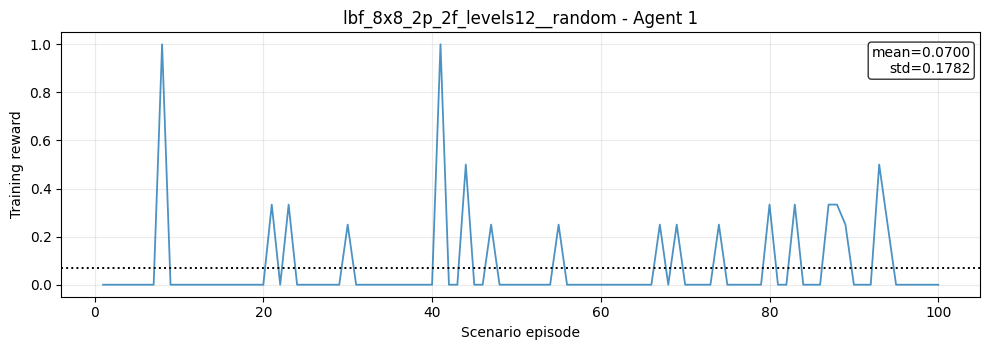

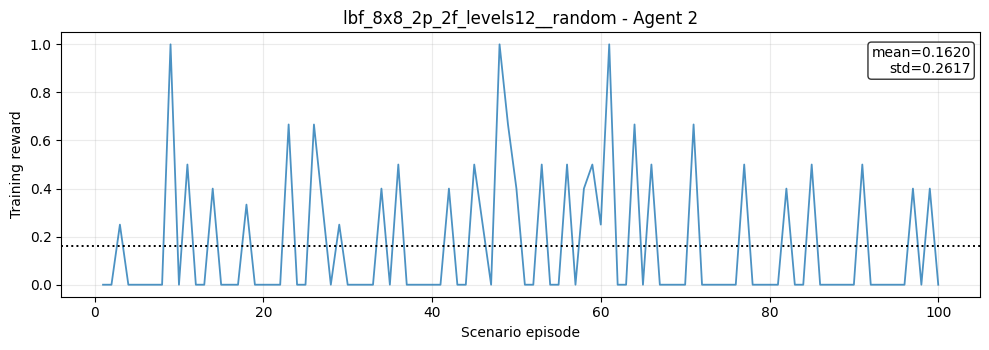

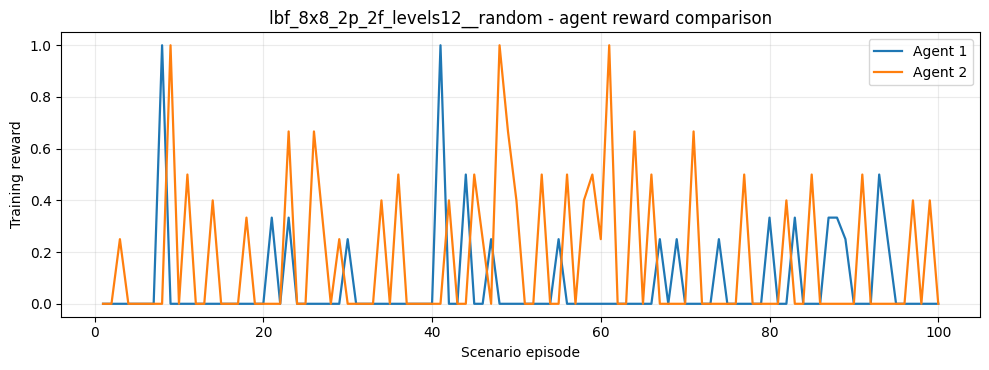

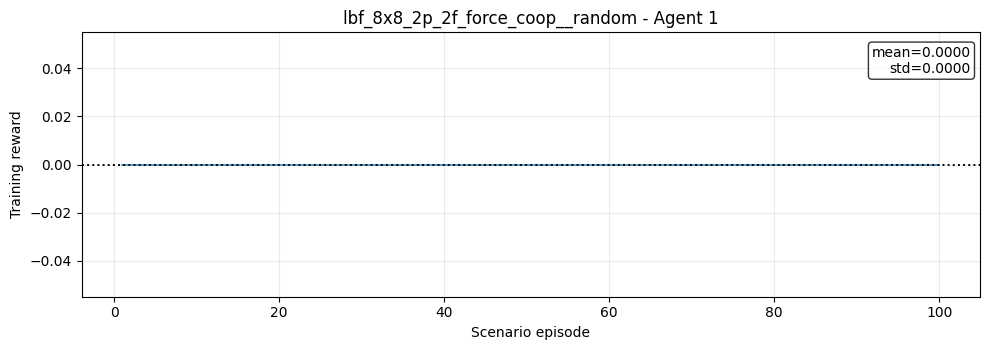

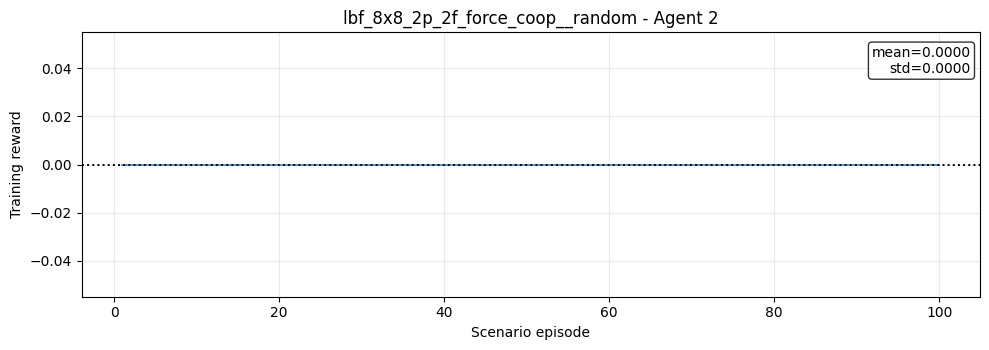

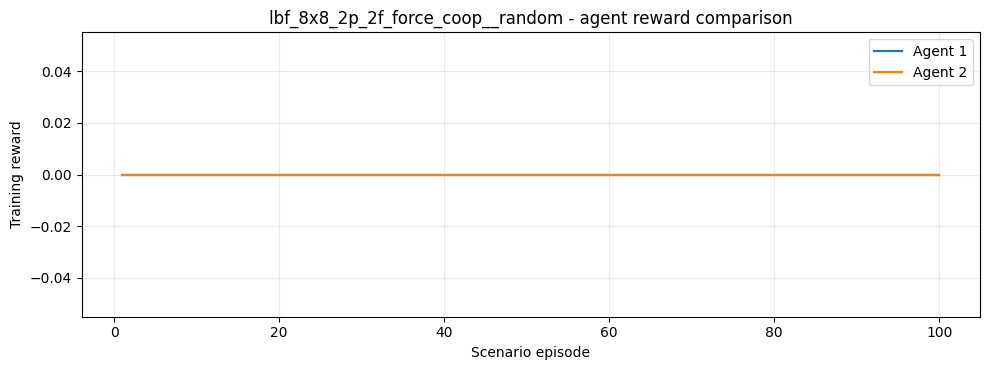

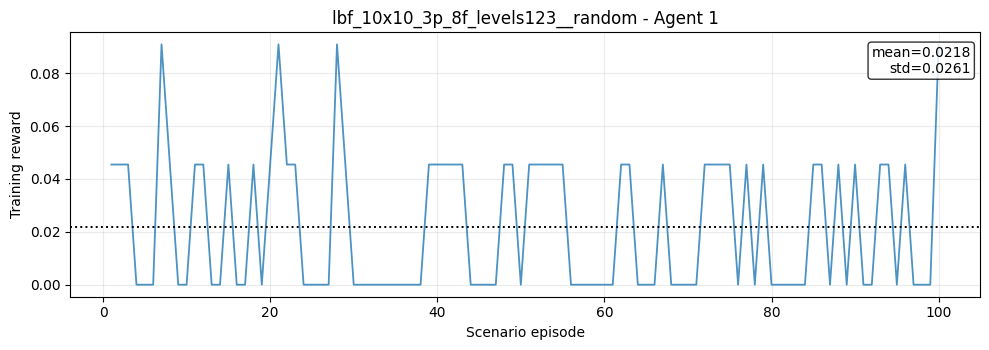

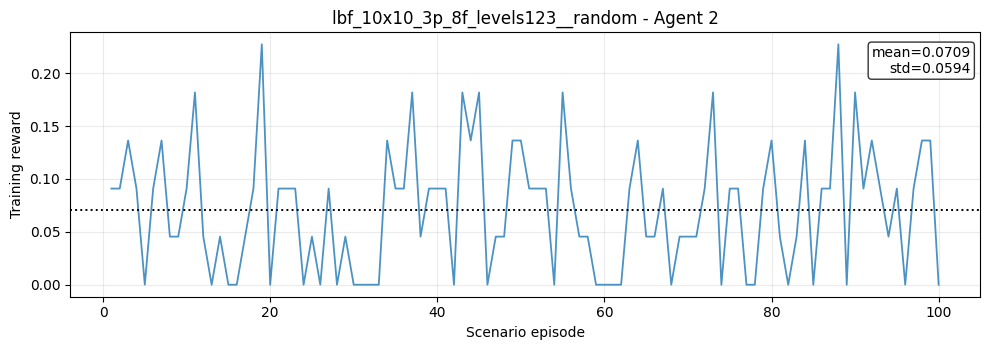

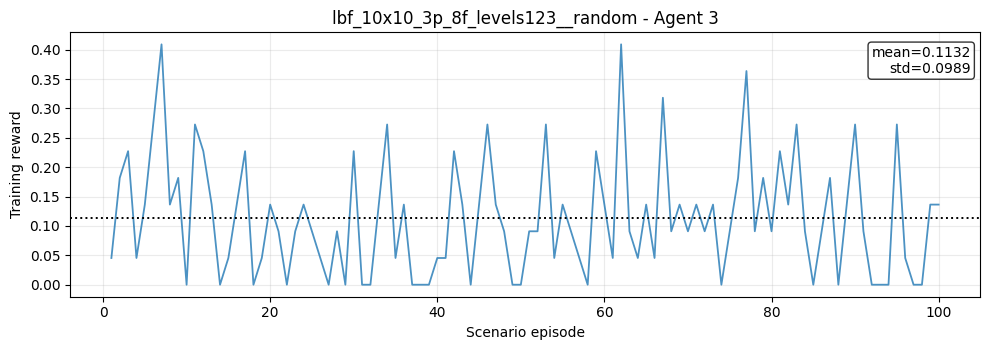

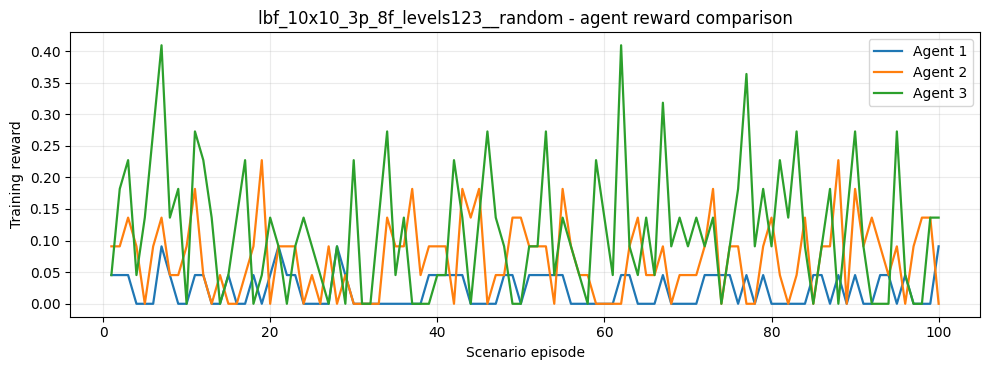

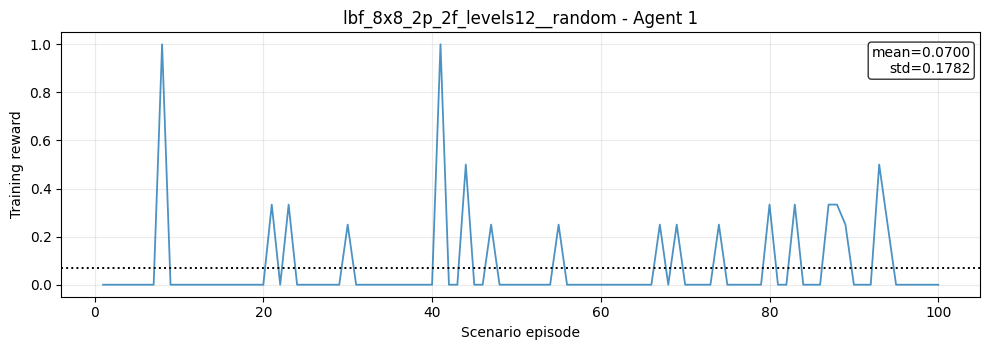

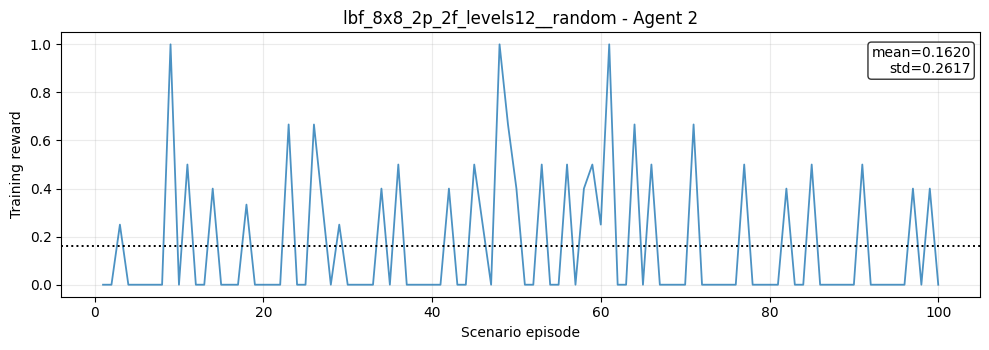

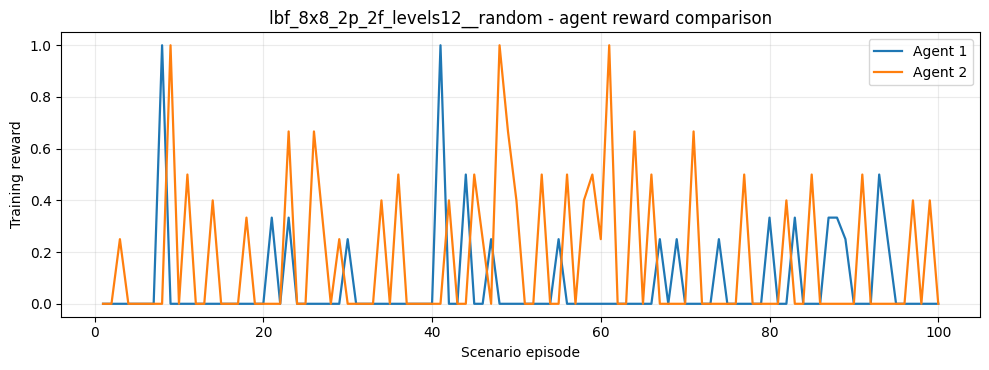

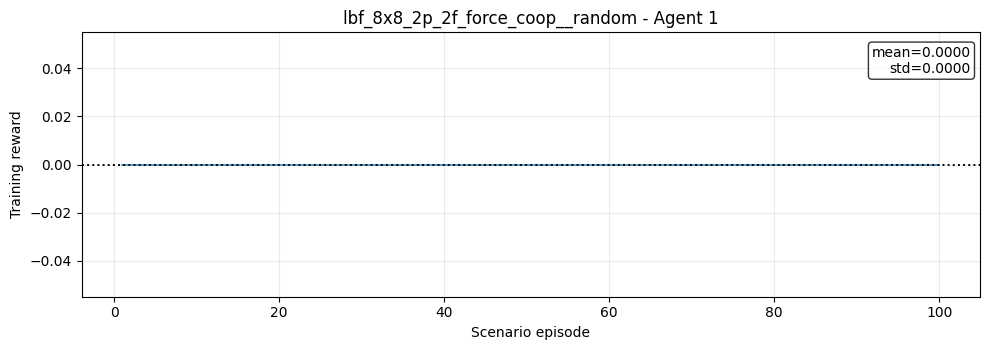

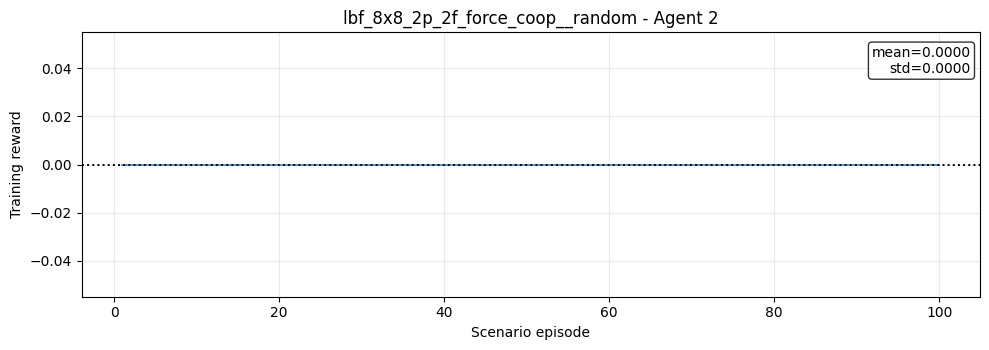

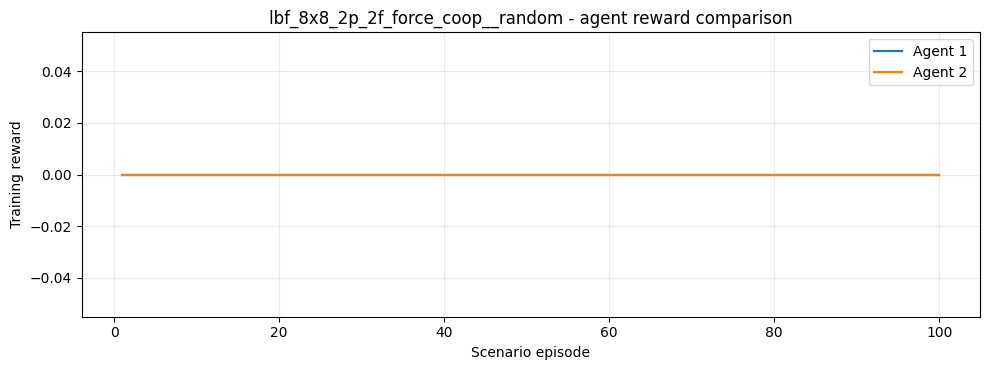

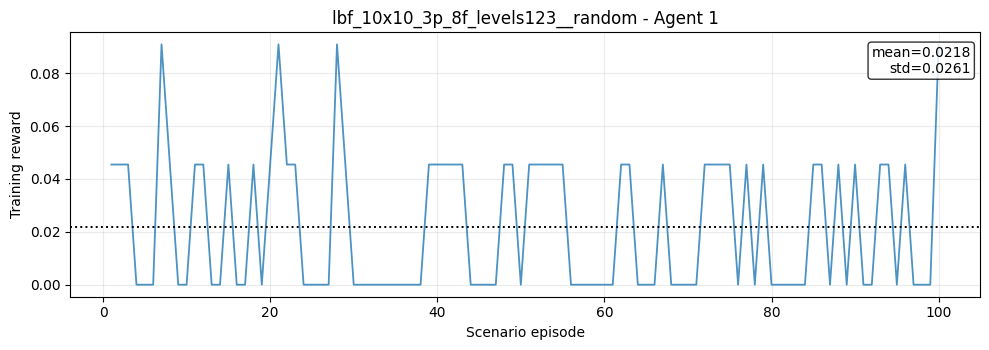

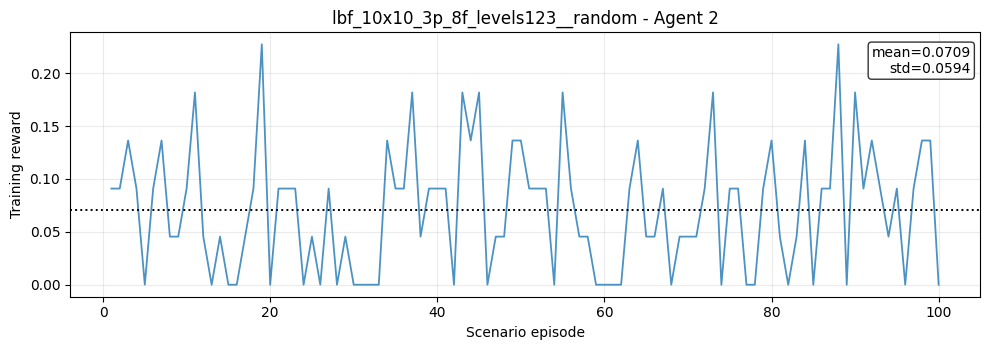

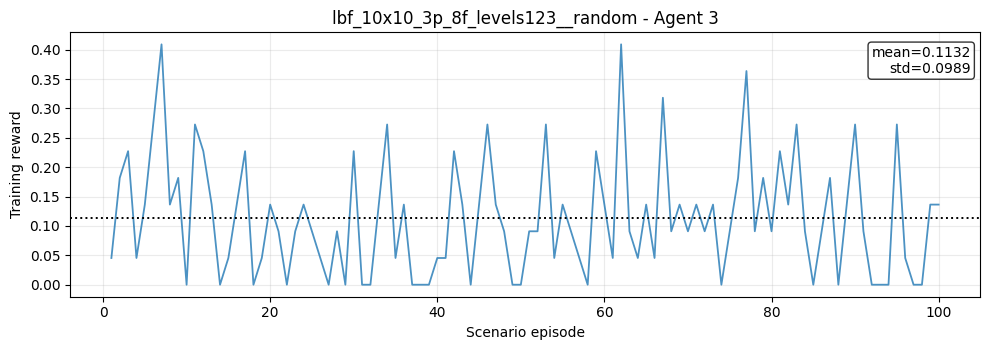

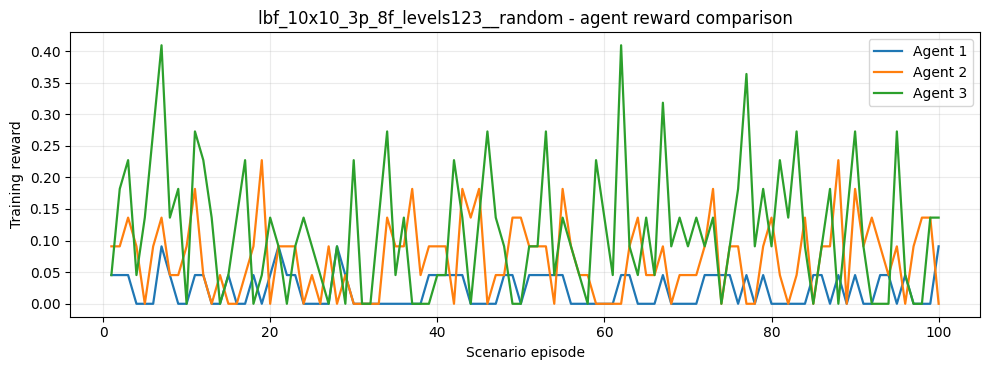

In [6]:
random_training_figs = plot_training_rewards(records_random)


## Random Evaluation Rollouts

For each scenario: run evaluation episodes, show the first rollout video if rendering works, then show one per-agent reward boxplot.

Random lbf_8x8_2p_2f_levels12: 100 eval episode(s)
  agent_0: mean=0.0775, std=0.1721
  agent_1: mean=0.1758, std=0.2554


/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_levels12/random/random_rollout.gif

[rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_levels12/random/random_rollout.gif]


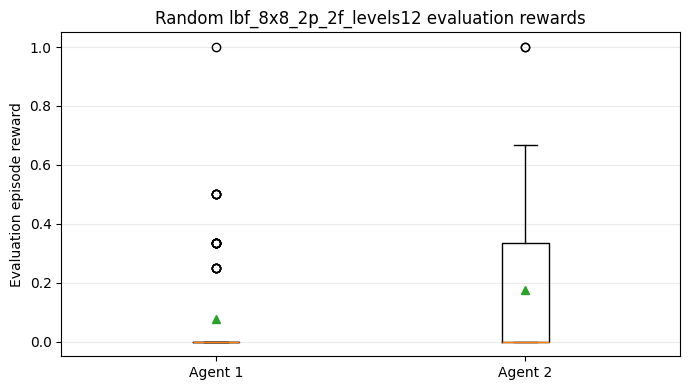

Random lbf_8x8_2p_2f_force_coop: 100 eval episode(s)
  agent_0: mean=0.0000, std=0.0000
  agent_1: mean=0.0000, std=0.0000


/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_force_coop/random/random_rollout.gif

[rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_8x8_2p_2f_force_coop/random/random_rollout.gif]


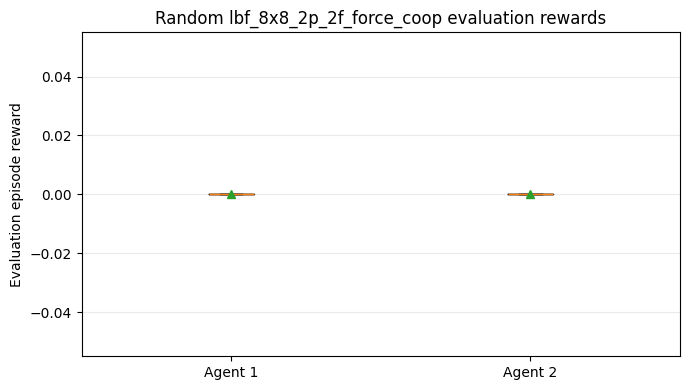

Random lbf_10x10_3p_8f_levels123: 100 eval episode(s)
  agent_0: mean=0.0186, std=0.0281
  agent_1: mean=0.0683, std=0.0573
  agent_2: mean=0.1345, std=0.1002


/home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_10x10_3p_8f_levels123/random/random_rollout.gif

[rollout video saved: /home/wowthecoder/SRE-DQN/discrete_action_space/lbf_grid/baseline_runs/epymarl/lbf_10x10_3p_8f_levels123/random/random_rollout.gif]


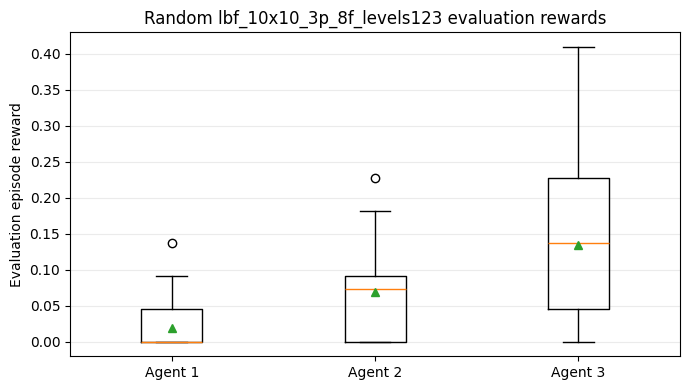

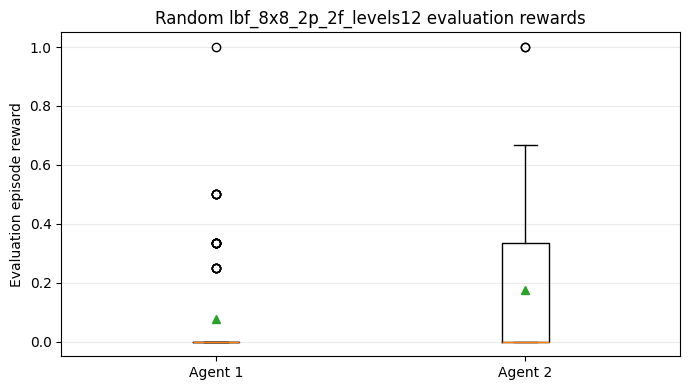

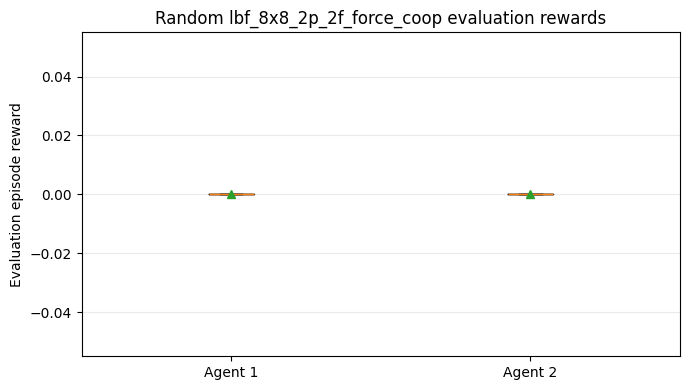

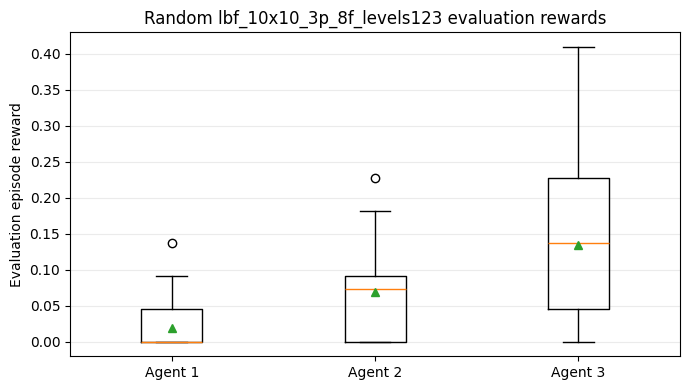

In [7]:
random_eval_rollouts = display_random_evaluation_rollouts(records_random)


## IQL Training

In [8]:
records_iql = []
for i, scenario_key in enumerate(SCENARIOS):
    record = run_epymarl_baseline(
        EPYMARL_ROOT,
        'iql',
        scenario_key,
        n_episodes=N_EPISODES,
        seed=SEED + 1000 * i + 1,
        output_root=OUTPUT_ROOT,
        common_reward=False,
        show_progress=True,
        config_overrides=CONFIG_OVERRIDES,
    )
    records_iql.append(record)
    print_stats(record)


/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
IQL lbf_8x8_2p_2f_levels12: 100%|████████████████████████████████████████████████| 5000/5000 [00:12<00:00, 392.83step/s]



-- IQL | 2 agents with levels 1 and 2, 8x8 grid, 2 foods, max food level 3, full sight, 50-step episodes --
  episodes : 100  |  t_max : 5,000  |  seed : 2026
  agent_0 final logged reward : 0.0690
  agent_0 last-100 mean       : 0.0690
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 0.1464
  agent_1 last-100 mean       : 0.1464
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 0.2154
  total last-100 mean       : 0.2154
  total episode axis        : env_step_scaled_to_requested_episode_budget


IQL lbf_8x8_2p_2f_force_coop: 100%|██████████████████████████████████████████████| 5000/5000 [00:14<00:00, 342.44step/s]



-- IQL | 2 level-1 agents, 8x8 grid, 2 level-2 foods, full sight, forced cooperation, 50-step episodes --
  episodes : 100  |  t_max : 5,000  |  seed : 3026
  agent_0 final logged reward : 0.0000
  agent_0 last-100 mean       : 0.0000
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 0.0000
  agent_1 last-100 mean       : 0.0000
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 0.0000
  total last-100 mean       : 0.0000
  total episode axis        : env_step_scaled_to_requested_episode_budget


IQL lbf_10x10_3p_8f_levels123: 100%|███████████████████████████████████████████| 10000/10000 [00:15<00:00, 658.20step/s]


-- IQL | 3 agents with levels 1, 2, and 3, 10x10 grid, 8 foods including one level-6 food, full sight, 100-step episodes --
  episodes : 100  |  t_max : 10,000  |  seed : 4026
  agent_0 final logged reward : 0.0135
  agent_0 last-100 mean       : 0.0135
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 0.0767
  agent_1 last-100 mean       : 0.0767
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_2 final logged reward : 0.1548
  agent_2 last-100 mean       : 0.1548
  agent_2 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 0.2450
  total last-100 mean       : 0.2450
  total episode axis        : env_step_scaled_to_requested_episode_budget


## IQL Training Reward Plots

For each scenario: one line plot per agent with mean/std, then one combined agent-line plot.

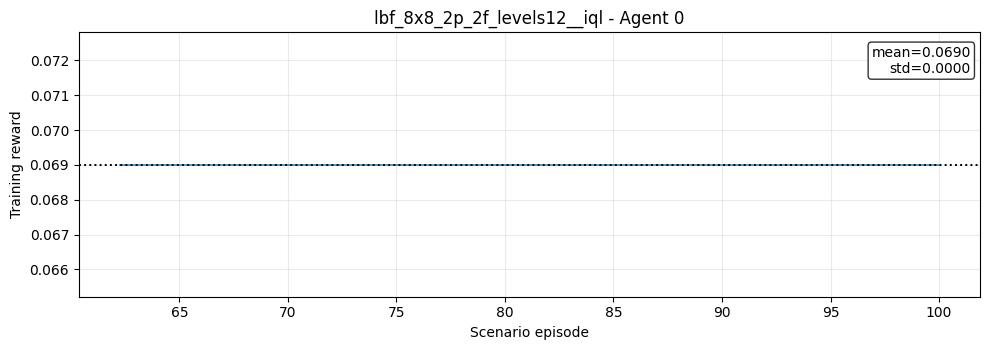

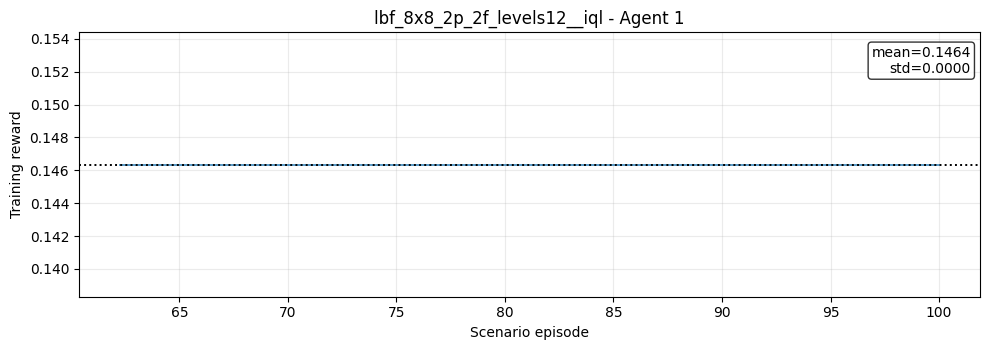

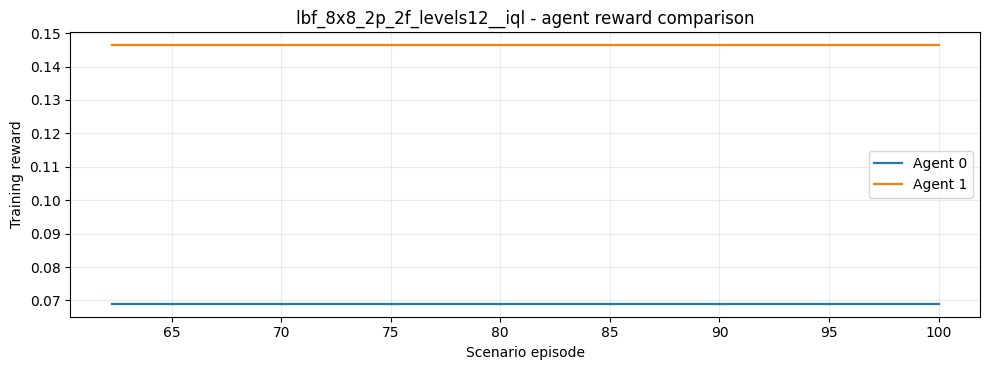

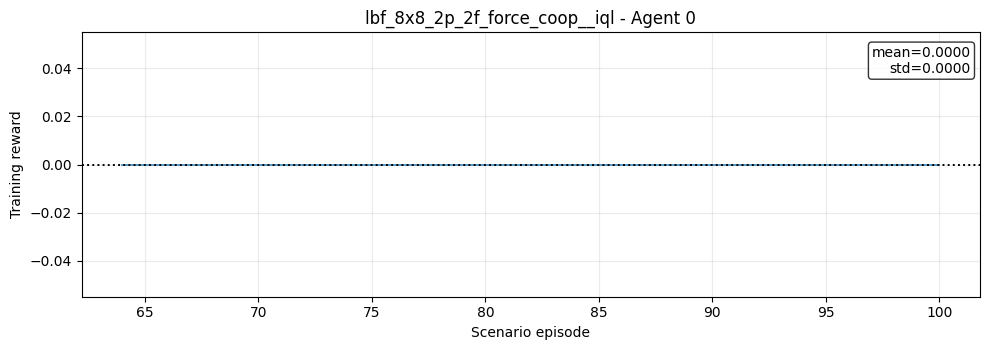

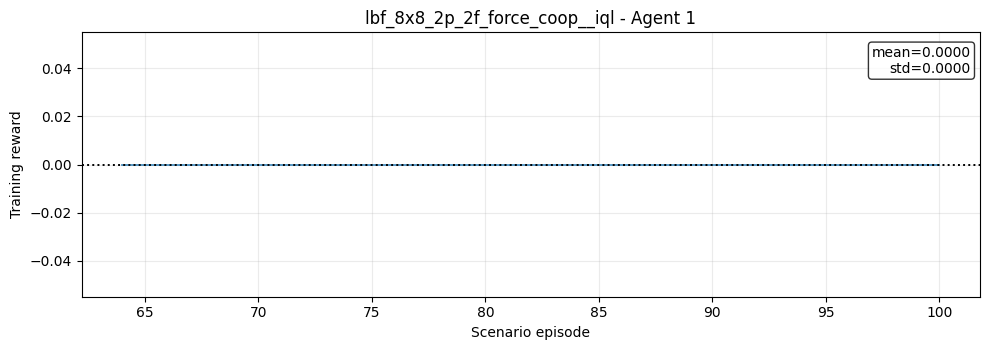

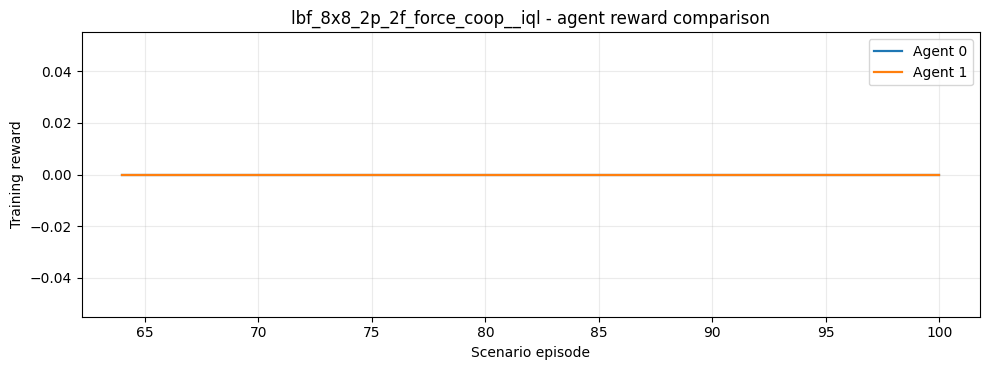

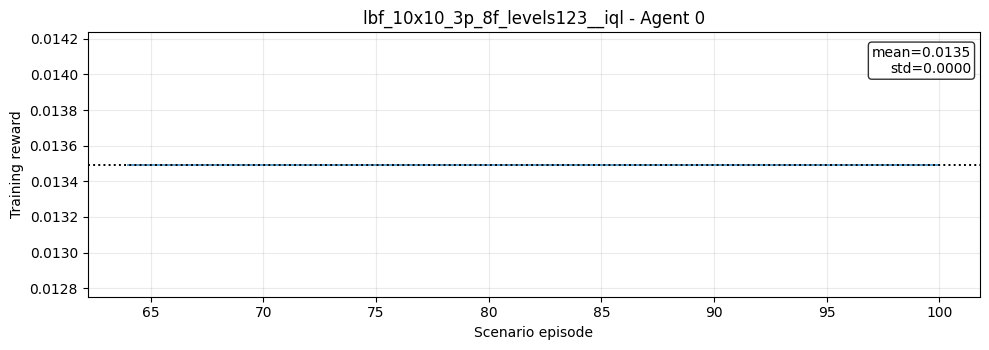

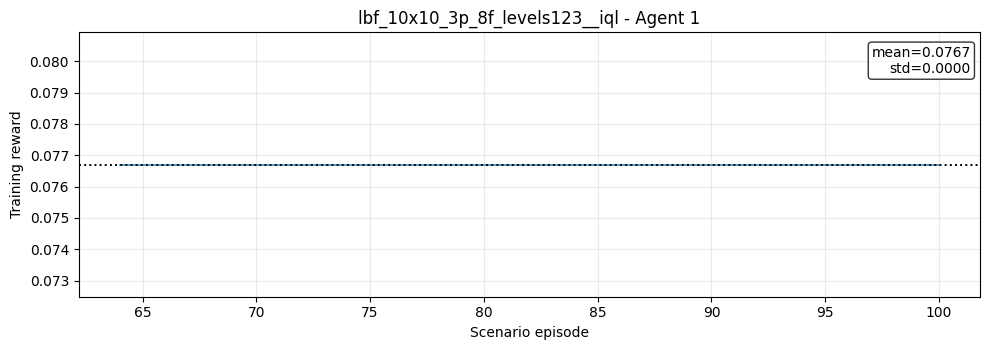

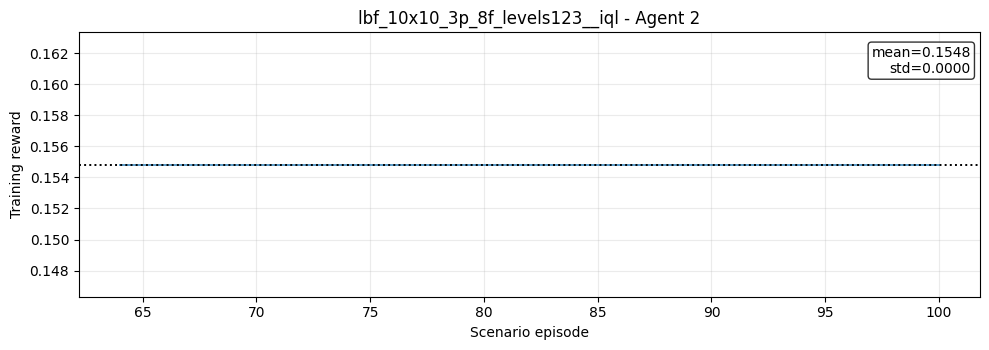

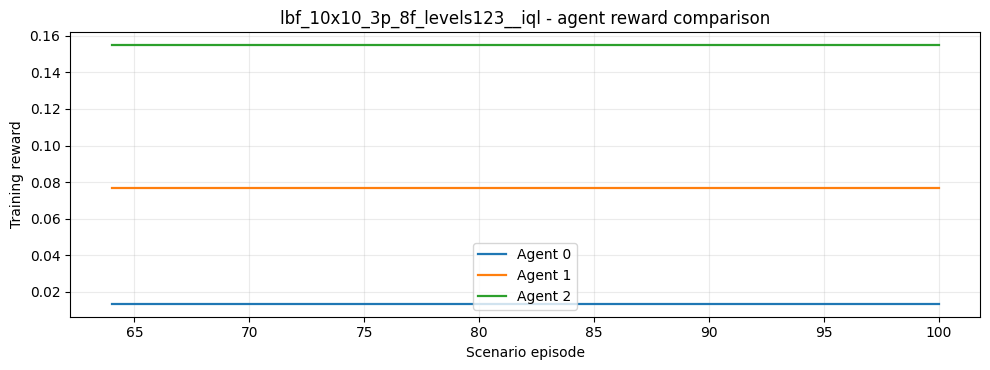

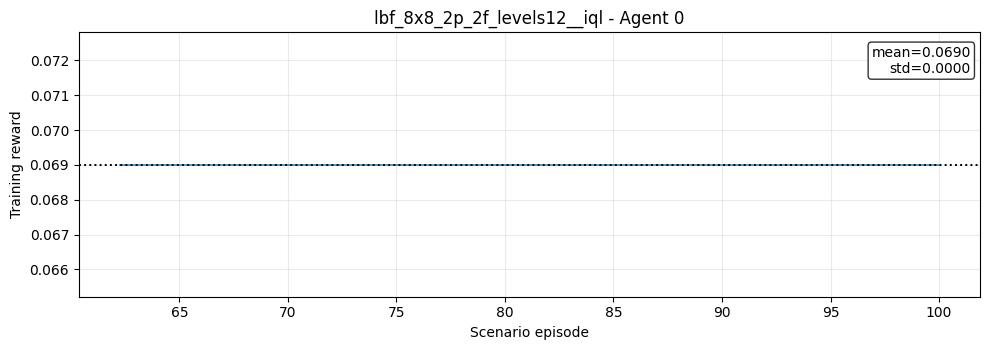

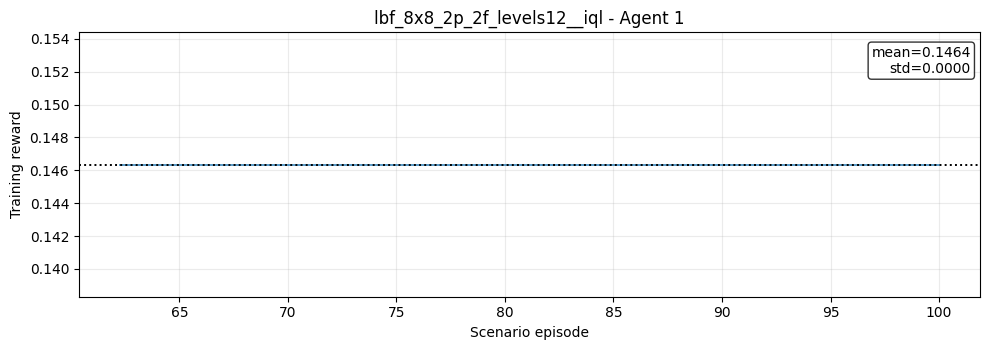

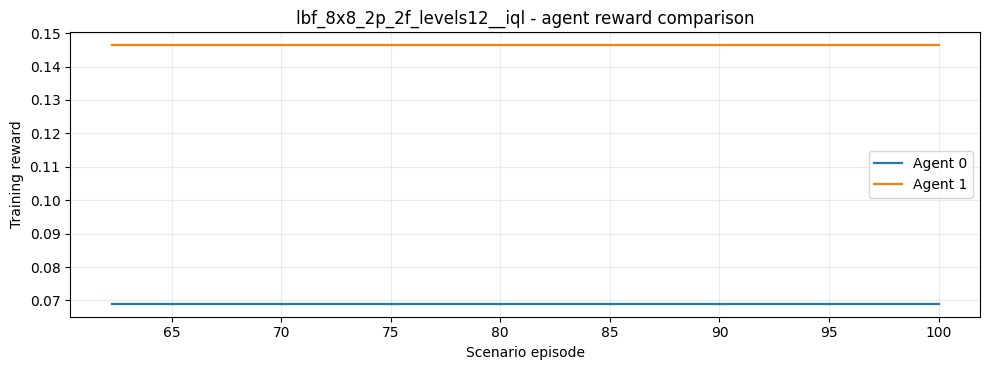

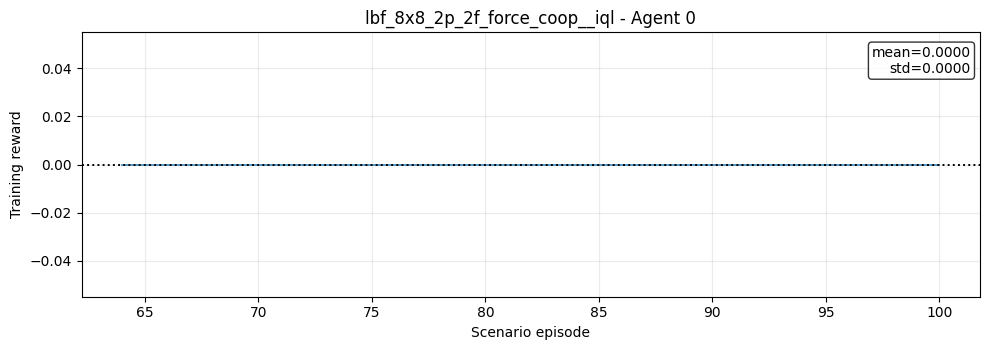

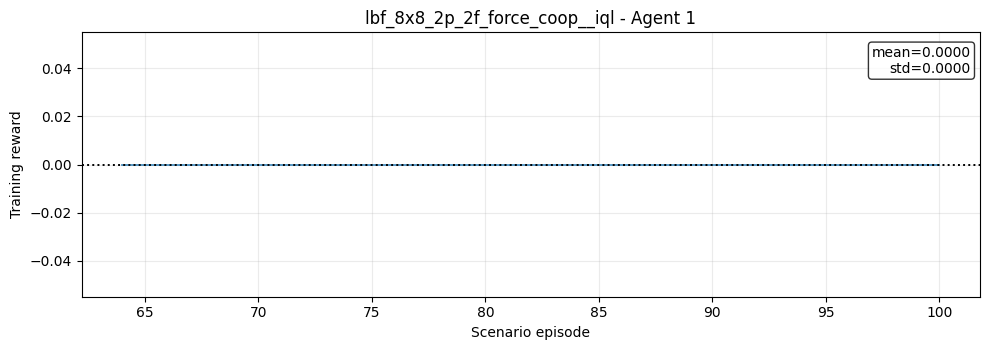

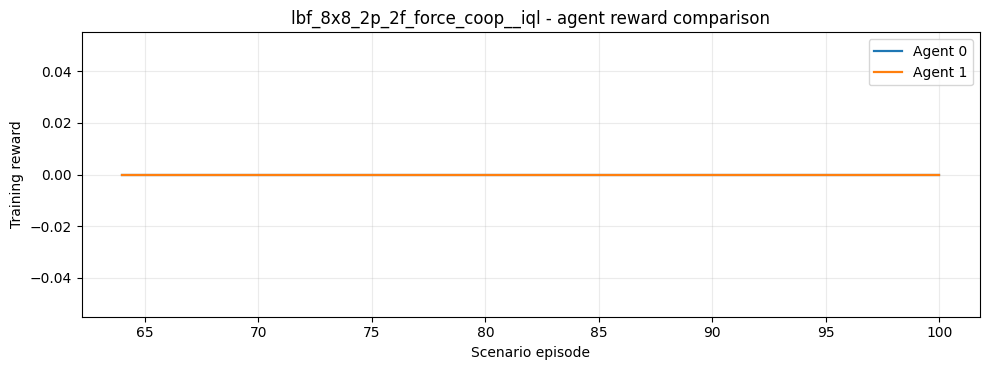

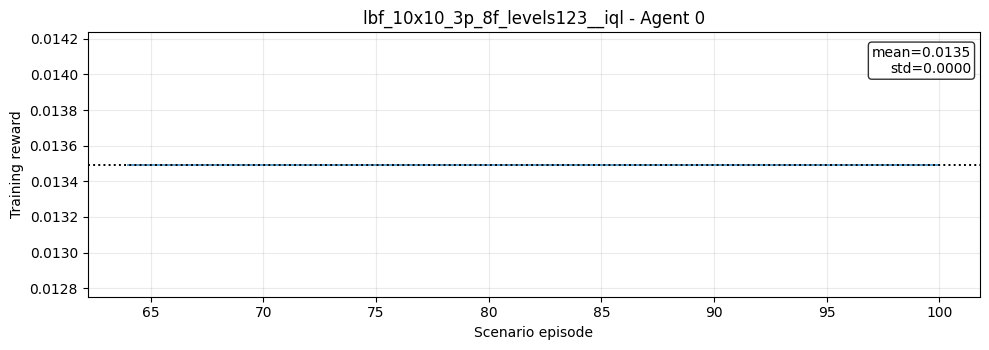

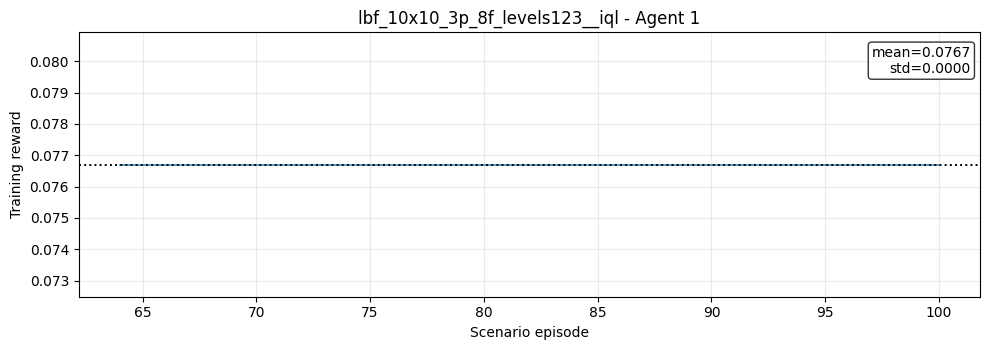

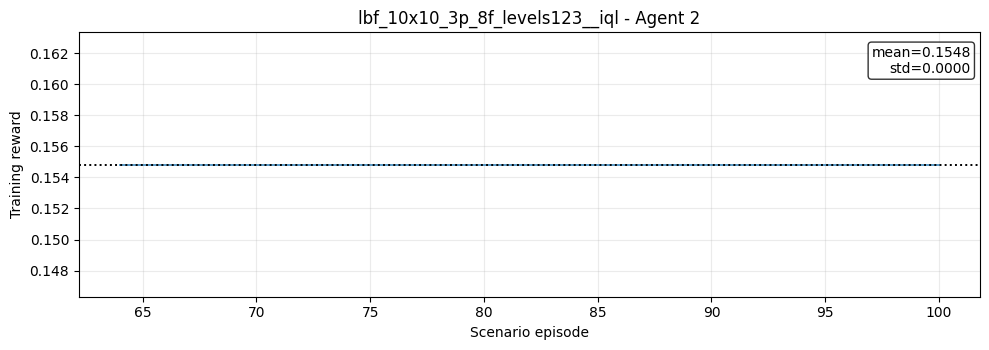

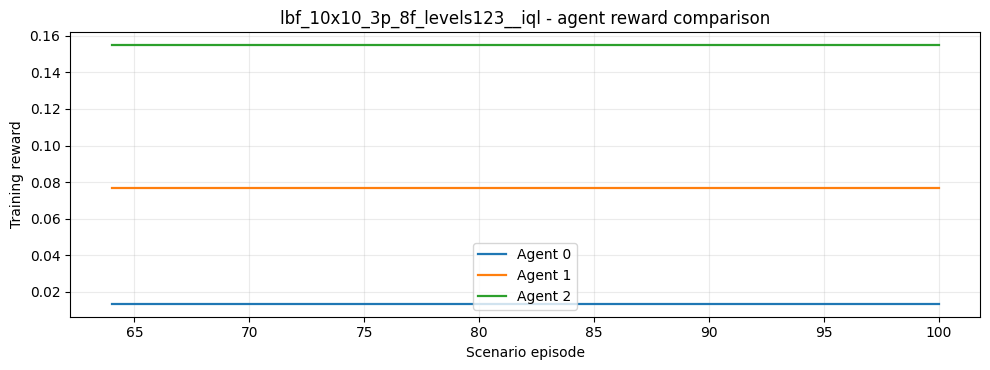

In [9]:
iql_training_figs = plot_training_rewards(records_iql)


## IQL Evaluation Rollouts

For each scenario: run checkpoint evaluation episodes and show one per-agent reward boxplot. Video is skipped for EPyMARL Gymma checkpoints because that path does not expose notebook RGB frames.

IQL lbf_8x8_2p_2f_levels12 checkpoint eval (100 episode) returncode=0
is will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  target[k][_slices] = v.view_as(target[k][_slices])
/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'list'>
  logger.warn(
/home/wowthecoder/epymarl/src/components/episode_buffer.py:110: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_

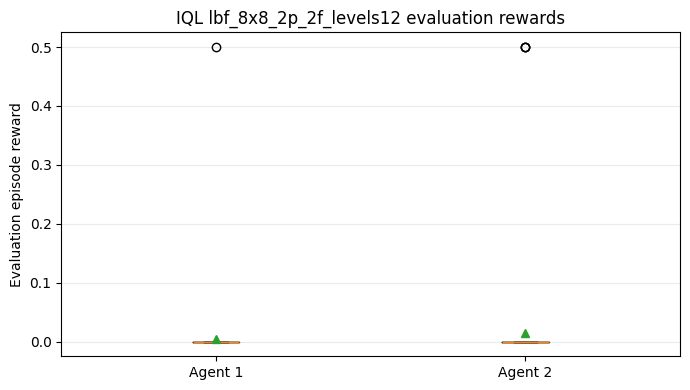

IQL lbf_8x8_2p_2f_force_coop checkpoint eval (100 episode) returncode=0
is will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  target[k][_slices] = v.view_as(target[k][_slices])
/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'list'>
  logger.warn(
/home/wowthecoder/epymarl/src/components/episode_buffer.py:110: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/pytho

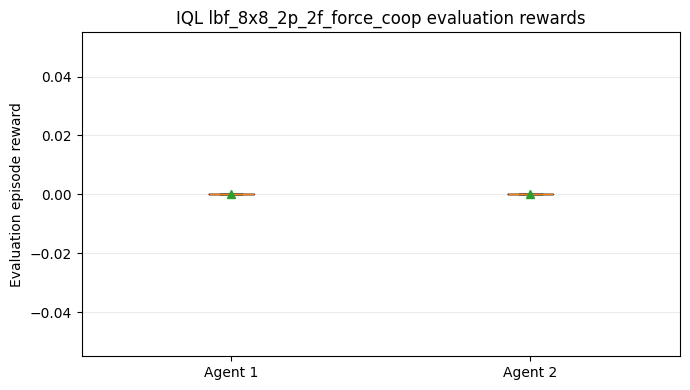

IQL lbf_10x10_3p_8f_levels123 checkpoint eval (100 episode) returncode=0
will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  target[k][_slices] = v.view_as(target[k][_slices])
/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'list'>
  logger.warn(
/home/wowthecoder/epymarl/src/components/episode_buffer.py:110: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  v = target[k][_slices]
/home/wowthe

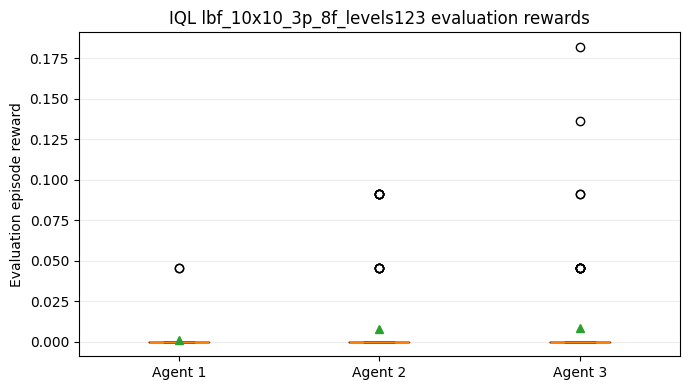

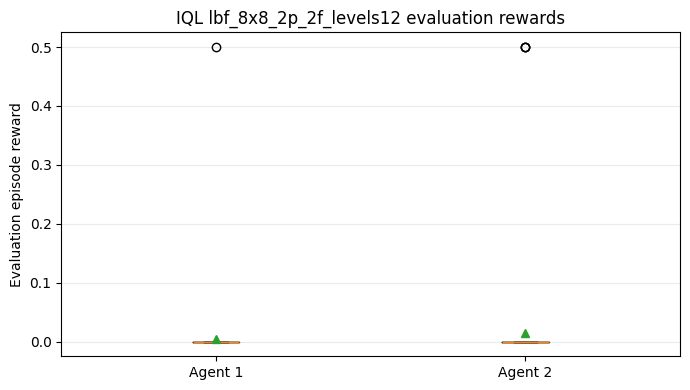

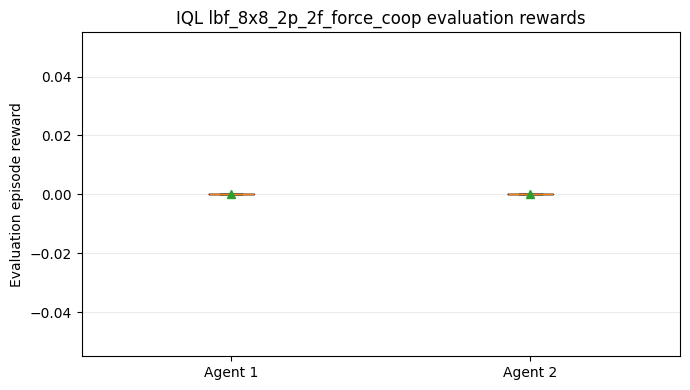

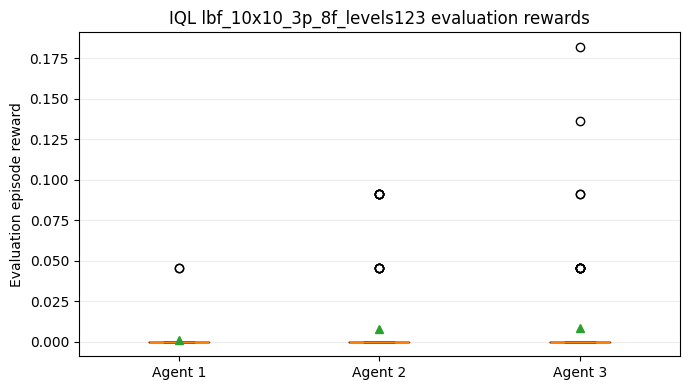

In [10]:
iql_eval_rollouts = run_epymarl_evaluation_rollouts(records_iql, common_reward=False)


## MAPPO Training

In [11]:
records_mappo = []
for i, scenario_key in enumerate(SCENARIOS):
    record = run_epymarl_baseline(
        EPYMARL_ROOT,
        'mappo',
        scenario_key,
        n_episodes=N_EPISODES,
        seed=SEED + 1000 * i + 2,
        output_root=OUTPUT_ROOT,
        common_reward=False,
        show_progress=True,
        config_overrides=CONFIG_OVERRIDES,
    )
    records_mappo.append(record)
    print_stats(record)


MAPPO lbf_8x8_2p_2f_levels12: 100%|██████████████████████████████████████████████| 5000/5000 [00:11<00:00, 431.74step/s]



-- MAPPO | 2 agents with levels 1 and 2, 8x8 grid, 2 foods, max food level 3, full sight, 50-step episodes --
  episodes : 100  |  t_max : 5,000  |  seed : 2027
  agent_0 final logged reward : 0.0404
  agent_0 last-100 mean       : 0.0404
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 0.1680
  agent_1 last-100 mean       : 0.1680
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 0.2083
  total last-100 mean       : 0.2083
  total episode axis        : env_step_scaled_to_requested_episode_budget


MAPPO lbf_8x8_2p_2f_force_coop: 100%|████████████████████████████████████████████| 5000/5000 [00:10<00:00, 468.82step/s]



-- MAPPO | 2 level-1 agents, 8x8 grid, 2 level-2 foods, full sight, forced cooperation, 50-step episodes --
  episodes : 100  |  t_max : 5,000  |  seed : 3027
  agent_0 final logged reward : 0.0000
  agent_0 last-100 mean       : 0.0000
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 0.0000
  agent_1 last-100 mean       : 0.0000
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 0.0000
  total last-100 mean       : 0.0000
  total episode axis        : env_step_scaled_to_requested_episode_budget


MAPPO lbf_10x10_3p_8f_levels123: 100%|█████████████████████████████████████████| 10000/10000 [00:15<00:00, 664.92step/s]


-- MAPPO | 3 agents with levels 1, 2, and 3, 10x10 grid, 8 foods including one level-6 food, full sight, 100-step episodes --
  episodes : 100  |  t_max : 10,000  |  seed : 4027
  agent_0 final logged reward : 0.0154
  agent_0 last-100 mean       : 0.0154
  agent_0 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_1 final logged reward : 0.0417
  agent_1 last-100 mean       : 0.0417
  agent_1 episode axis        : env_step_scaled_to_requested_episode_budget
  agent_2 final logged reward : 0.1119
  agent_2 last-100 mean       : 0.1119
  agent_2 episode axis        : env_step_scaled_to_requested_episode_budget
  total final logged reward : 0.1690
  total last-100 mean       : 0.1690
  total episode axis        : env_step_scaled_to_requested_episode_budget


## MAPPO Training Reward Plots

For each scenario: one line plot per agent with mean/std, then one combined agent-line plot.

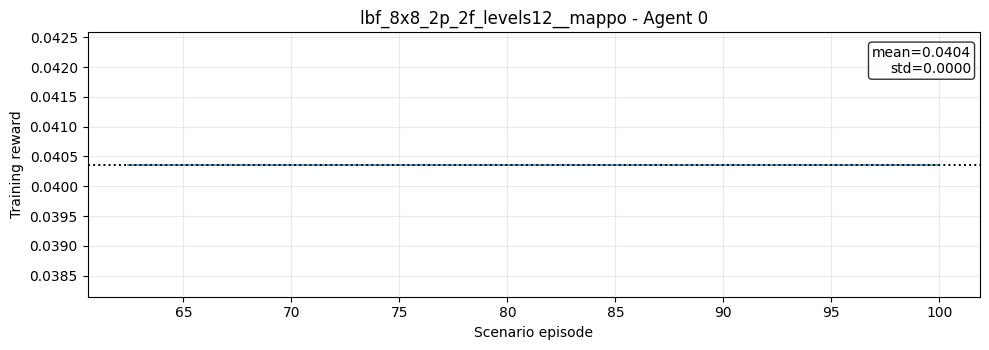

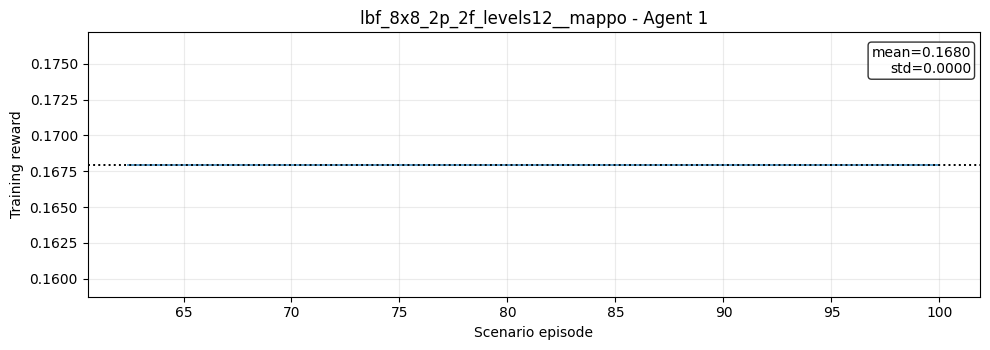

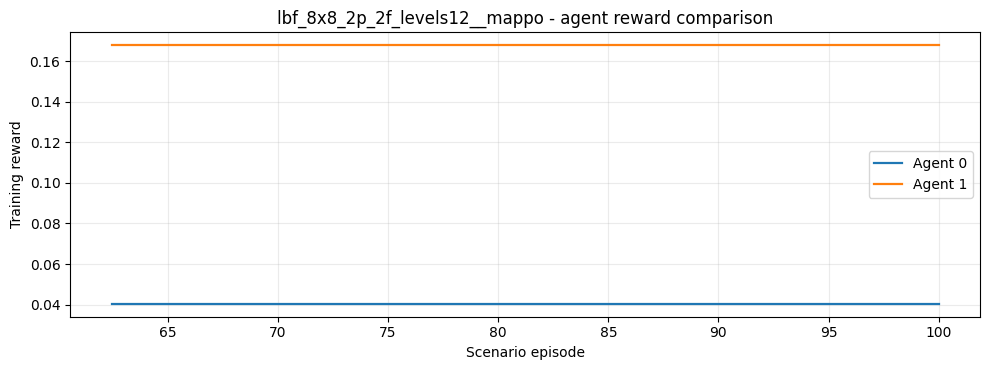

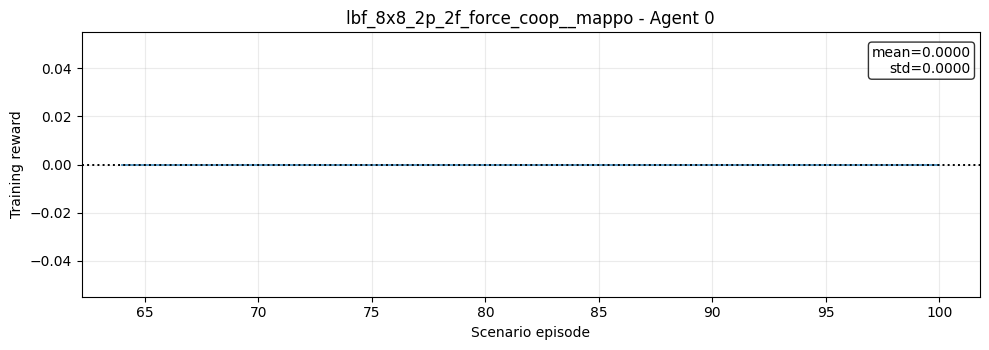

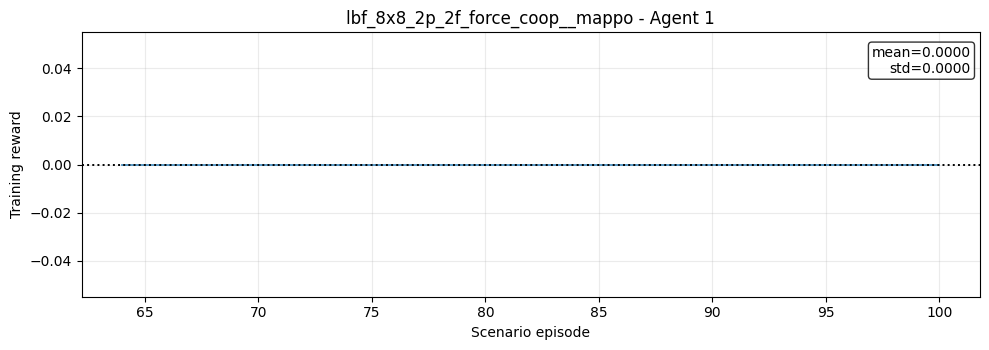

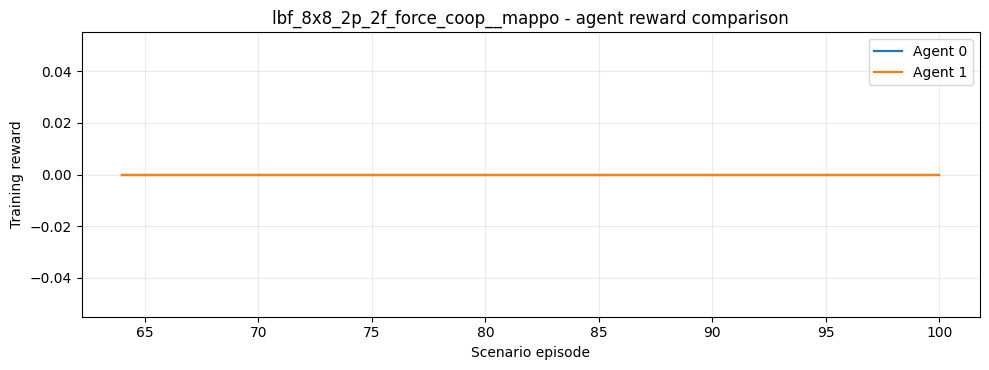

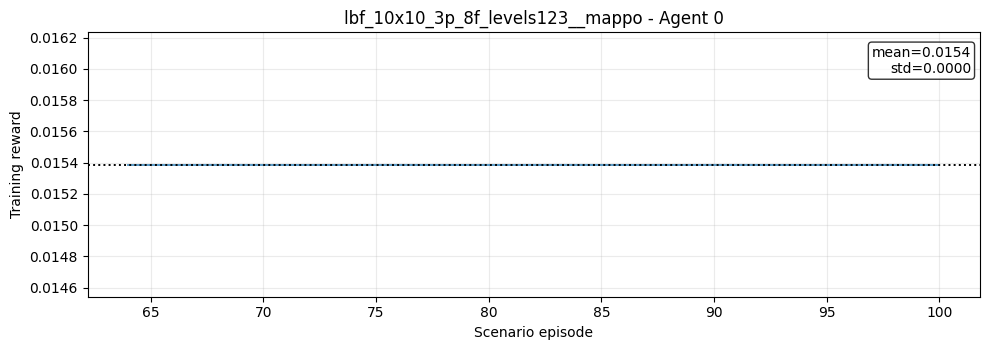

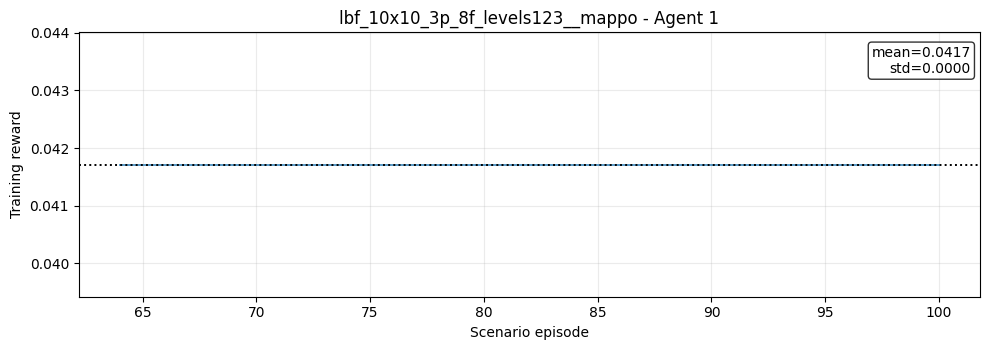

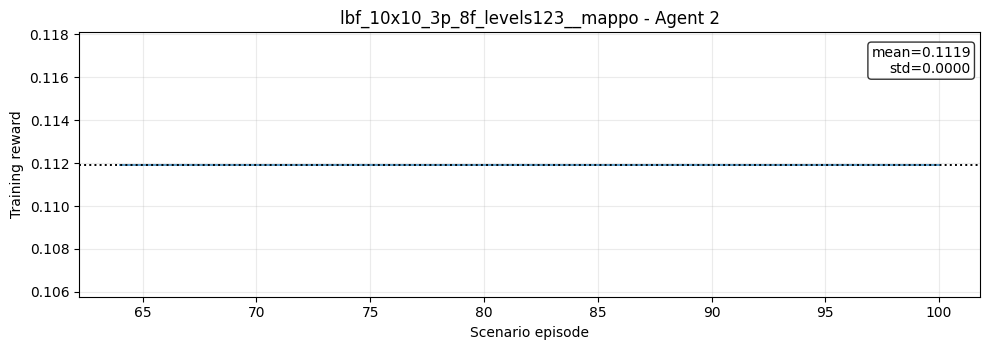

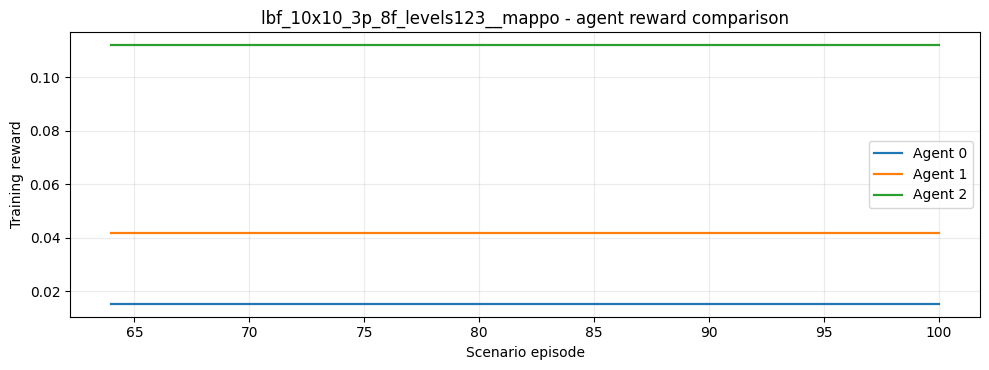

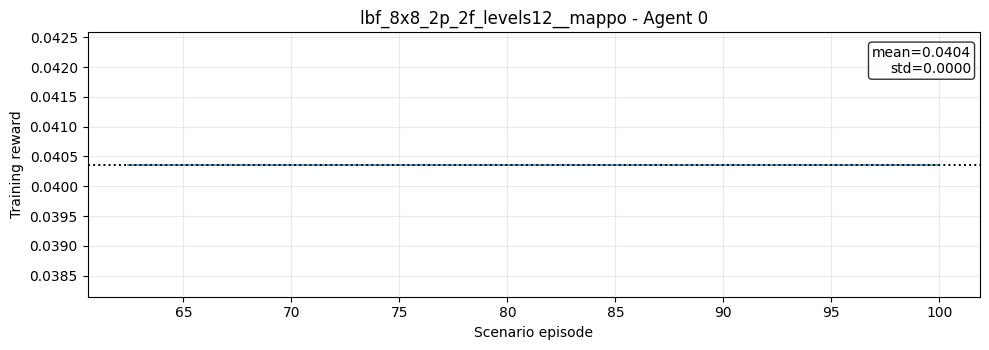

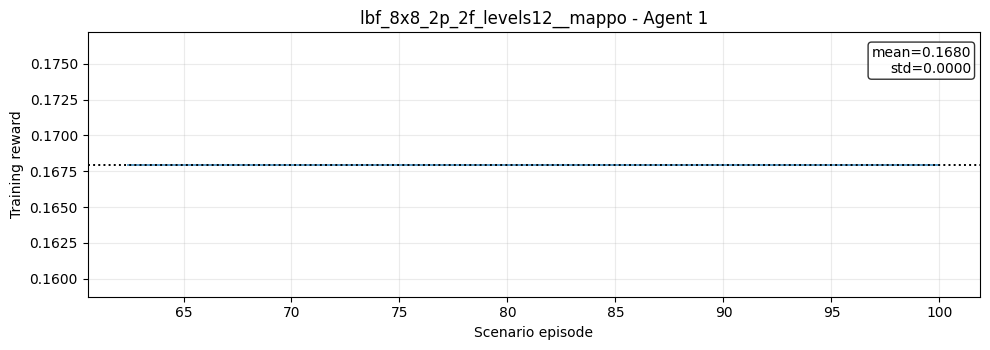

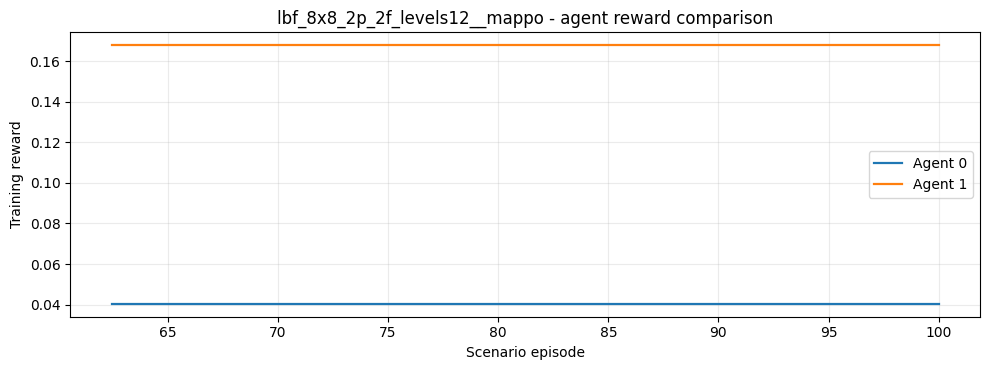

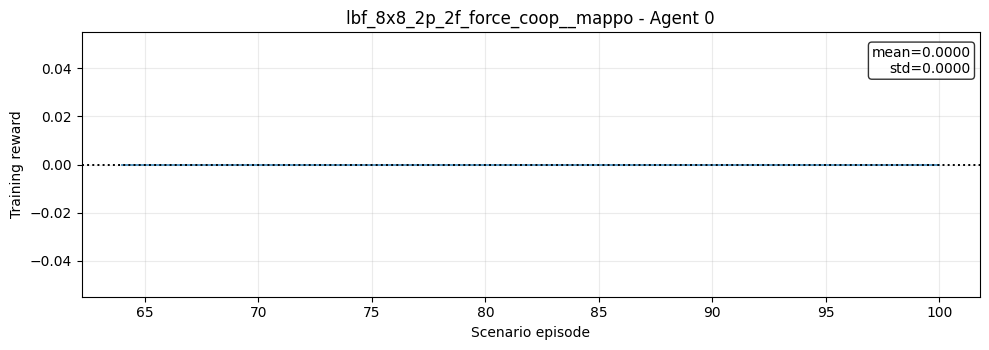

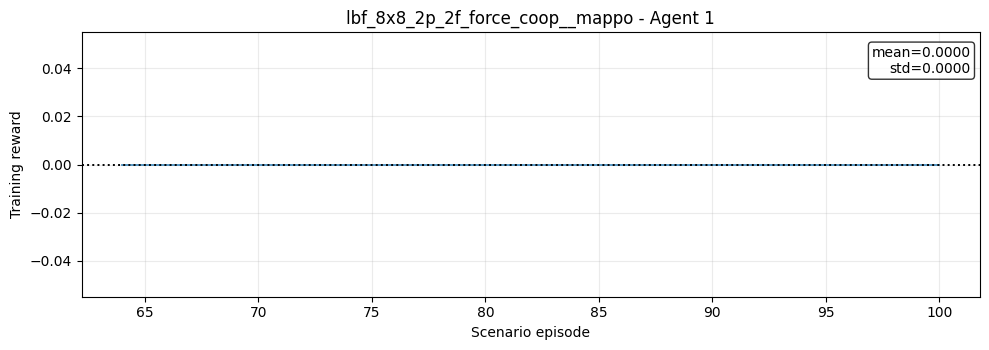

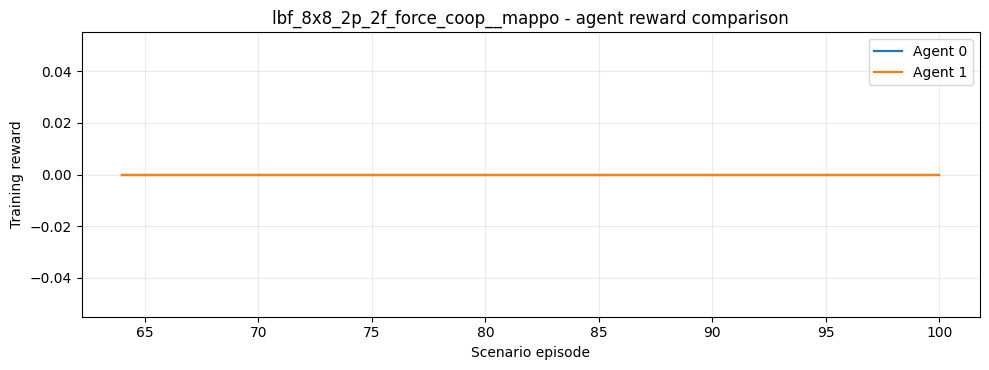

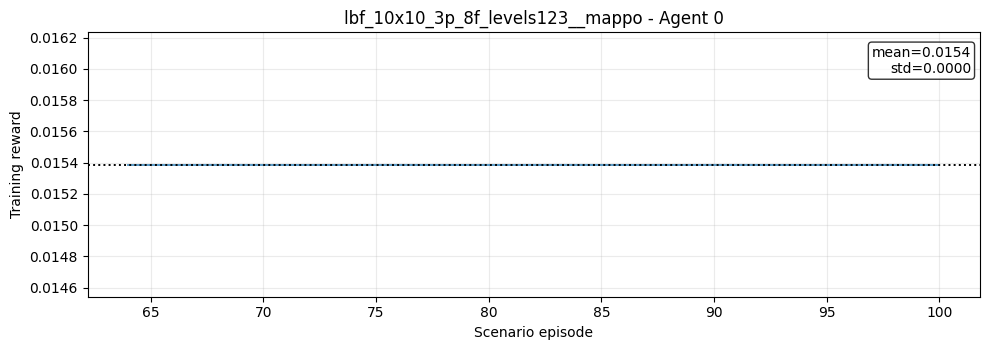

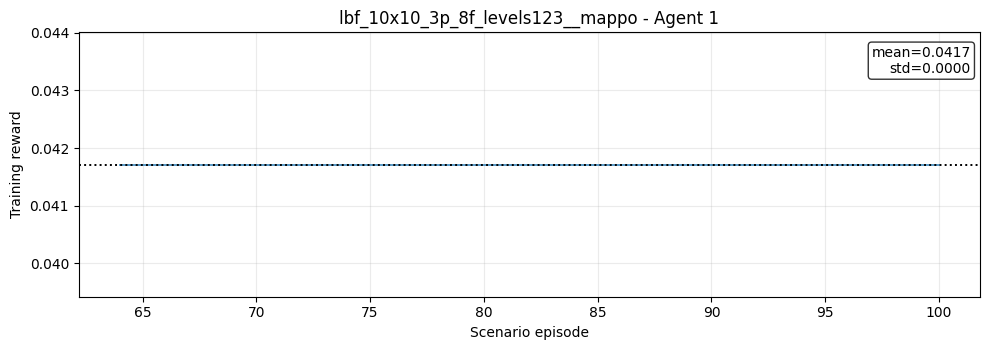

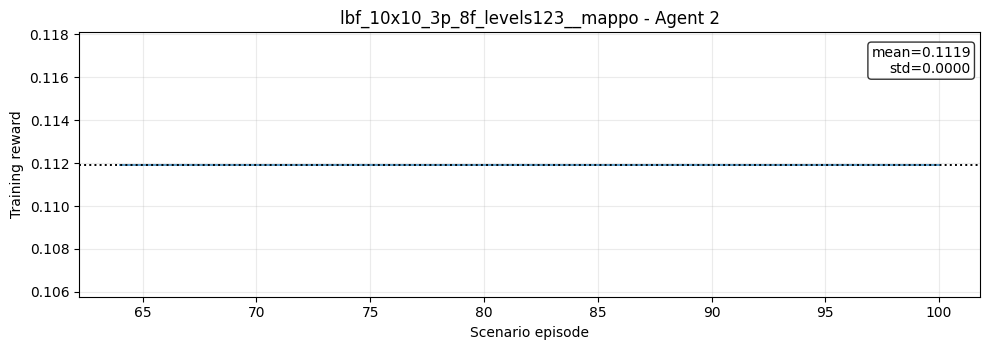

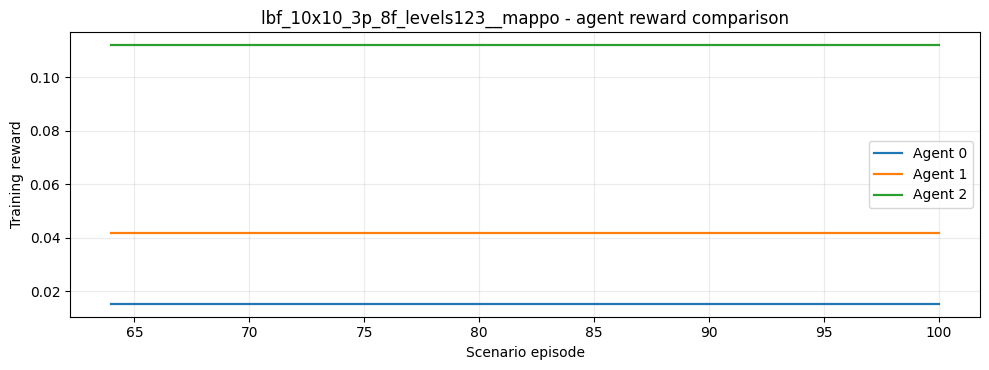

In [12]:
mappo_training_figs = plot_training_rewards(records_mappo)


## MAPPO Evaluation Rollouts

For each scenario: run checkpoint evaluation episodes and show one per-agent reward boxplot. Video is skipped for EPyMARL Gymma checkpoints because that path does not expose notebook RGB frames.

MAPPO lbf_8x8_2p_2f_levels12 checkpoint eval (100 episode) returncode=0
is will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  target[k][_slices] = v.view_as(target[k][_slices])
/home/wowthecoder/epymarl/src/components/episode_buffer.py:110: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  v = target[k][_slices]
/home/wowthecoder/epymarl/src/components/episode_buffer.py:113: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tu

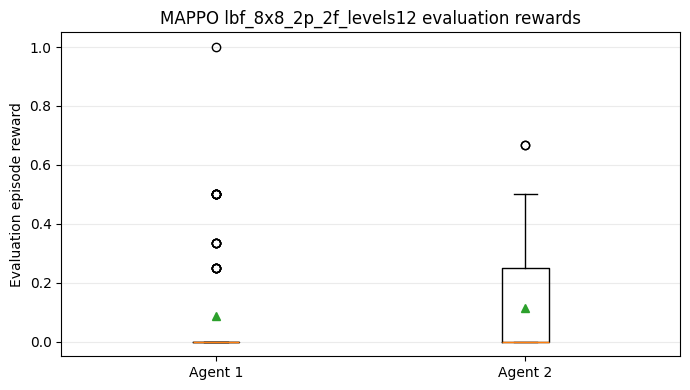

MAPPO lbf_8x8_2p_2f_force_coop checkpoint eval (100 episode) returncode=0
is will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  target[k][_slices] = v.view_as(target[k][_slices])
/home/wowthecoder/epymarl/src/components/episode_buffer.py:110: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  v = target[k][_slices]
/home/wowthecoder/epymarl/src/components/episode_buffer.py:113: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[

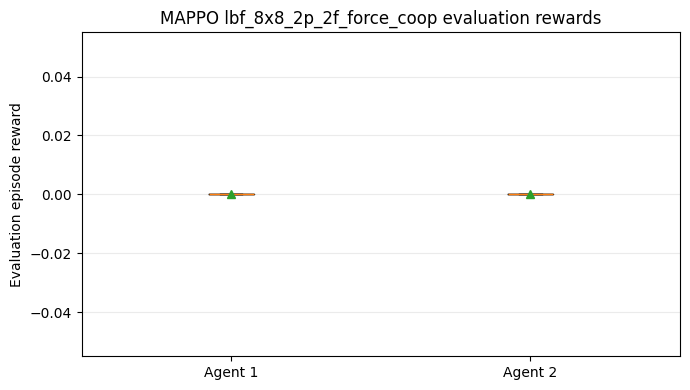

MAPPO lbf_10x10_3p_8f_levels123 checkpoint eval (100 episode) returncode=0
will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  target[k][_slices] = v.view_as(target[k][_slices])
/home/wowthecoder/epymarl/src/components/episode_buffer.py:110: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  v = target[k][_slices]
/home/wowthecoder/epymarl/src/components/episode_buffer.py:113: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpre

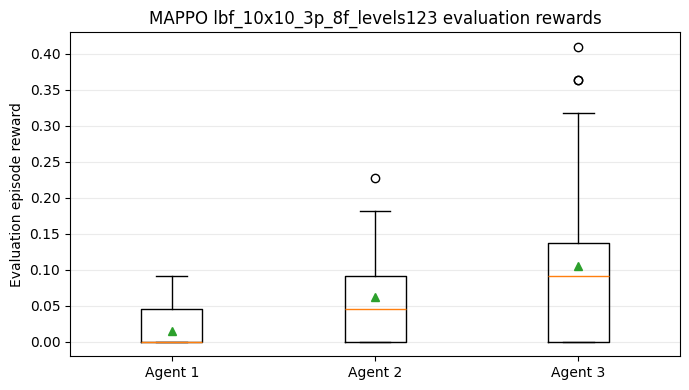

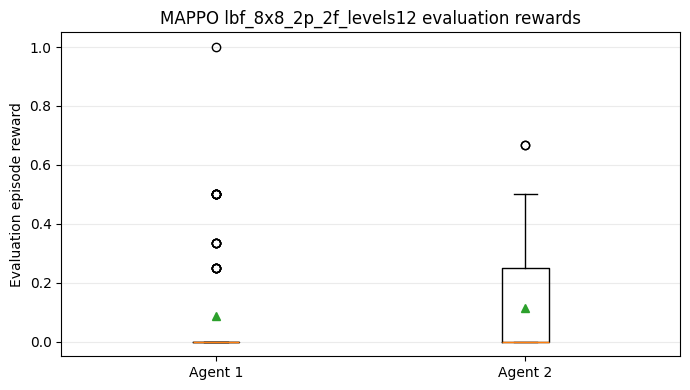

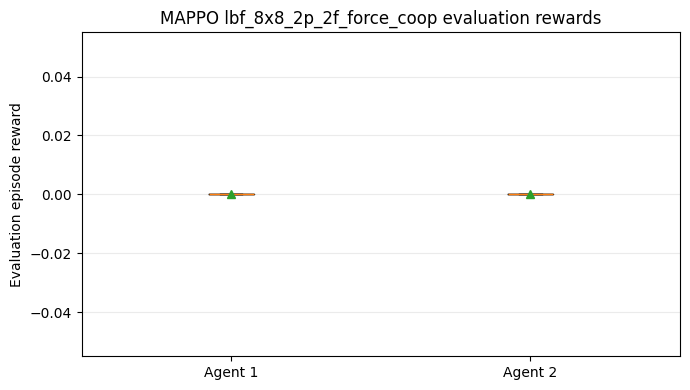

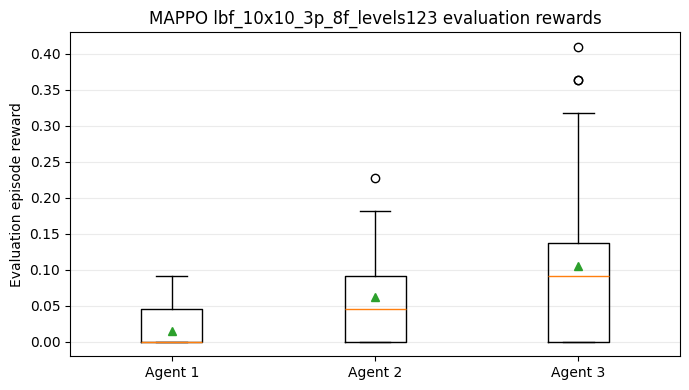

In [13]:
mappo_eval_rollouts = run_epymarl_evaluation_rollouts(records_mappo, common_reward=False)


## QMIX Training

In [14]:
records_qmix = []
for i, scenario_key in enumerate(SCENARIOS):
    record = run_epymarl_baseline(
        EPYMARL_ROOT,
        'qmix',
        scenario_key,
        n_episodes=N_EPISODES,
        seed=SEED + 1000 * i + 3,
        output_root=OUTPUT_ROOT,
        common_reward=True,
        show_progress=True,
        config_overrides=CONFIG_OVERRIDES,
    )
    records_qmix.append(record)
    print_stats(record)


QMIX lbf_8x8_2p_2f_levels12: 100%|███████████████████████████████████████████████| 5000/5000 [00:10<00:00, 472.27step/s]



-- QMIX | 2 agents with levels 1 and 2, 8x8 grid, 2 foods, max food level 3, full sight, 50-step episodes --
  episodes : 100  |  t_max : 5,000  |  seed : 2028
  shared final logged reward : 0.2229
  shared last-100 mean       : 0.2229
  shared episode axis        : env_step_scaled_to_requested_episode_budget


QMIX lbf_8x8_2p_2f_force_coop: 100%|█████████████████████████████████████████████| 5000/5000 [00:10<00:00, 474.78step/s]



-- QMIX | 2 level-1 agents, 8x8 grid, 2 level-2 foods, full sight, forced cooperation, 50-step episodes --
  episodes : 100  |  t_max : 5,000  |  seed : 3028
  shared final logged reward : 0.0078
  shared last-100 mean       : 0.0078
  shared episode axis        : env_step_scaled_to_requested_episode_budget


QMIX lbf_10x10_3p_8f_levels123: 100%|██████████████████████████████████████████| 10000/10000 [00:12<00:00, 819.89step/s]


-- QMIX | 3 agents with levels 1, 2, and 3, 10x10 grid, 8 foods including one level-6 food, full sight, 100-step episodes --
  episodes : 100  |  t_max : 10,000  |  seed : 4028
  shared final logged reward : 0.2230
  shared last-100 mean       : 0.2230
  shared episode axis        : env_step_scaled_to_requested_episode_budget


## QMIX Training Reward Plots

QMIX is trained with a shared/common reward, so the training plot is a shared reward curve when per-agent curves are not available.

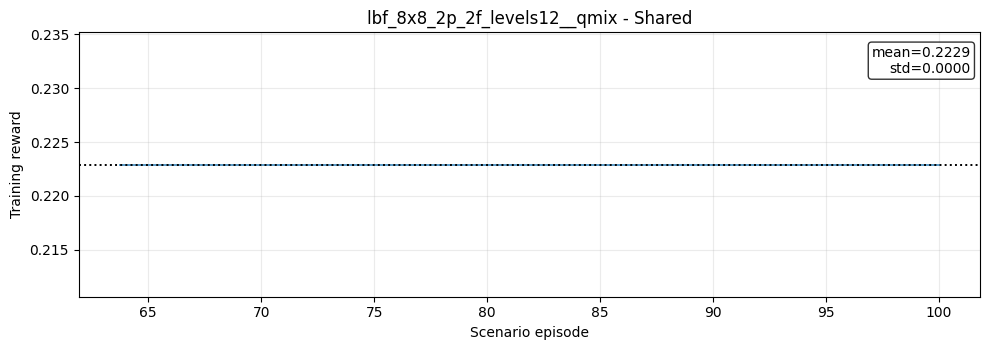

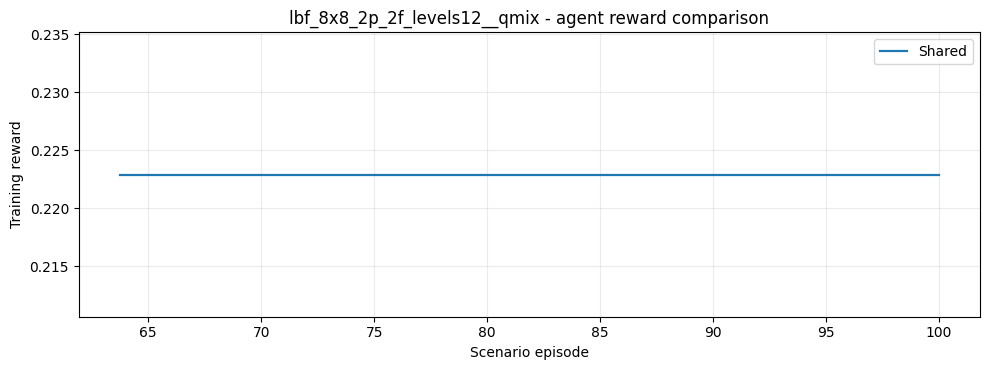

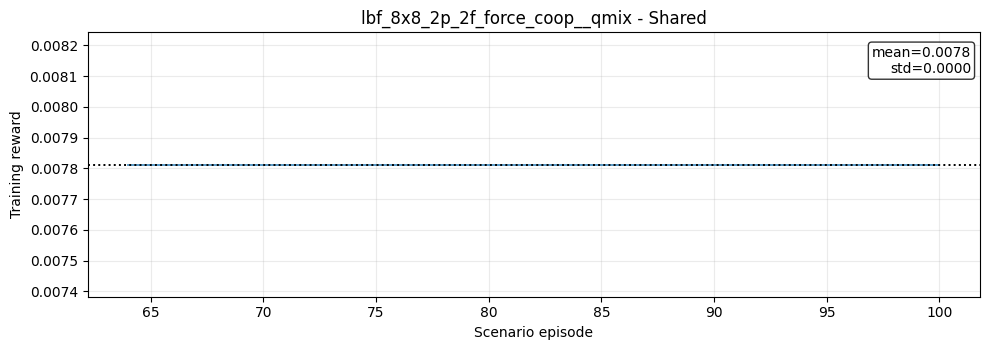

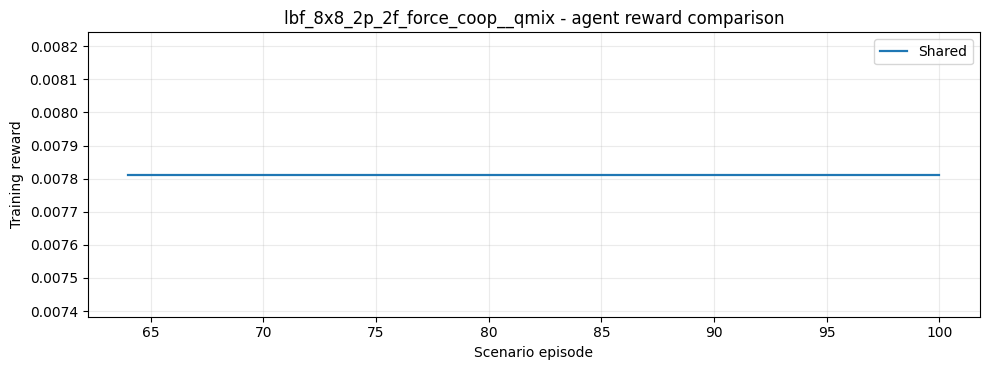

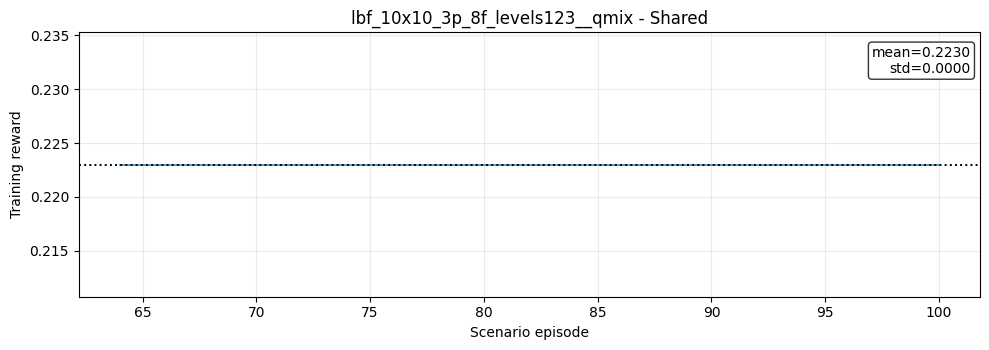

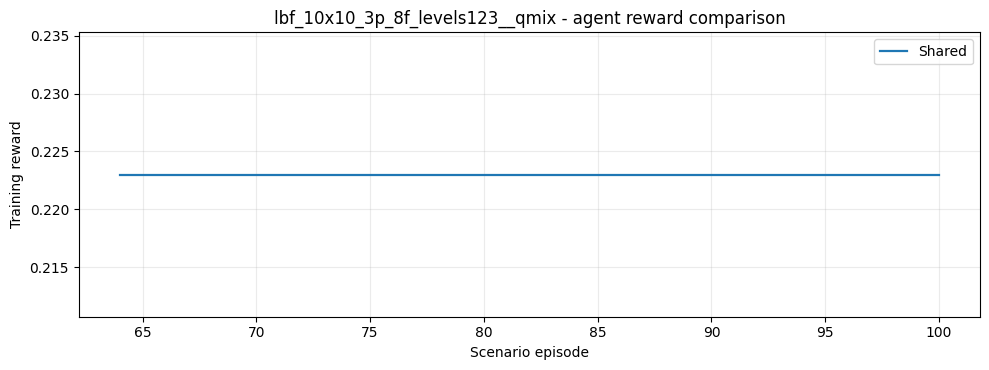

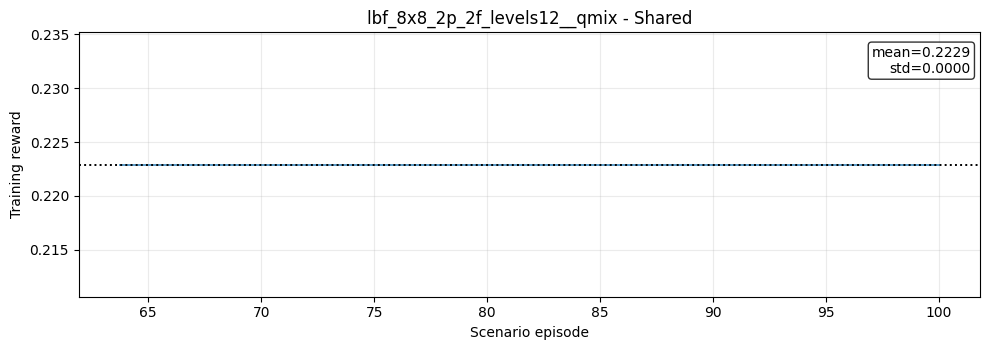

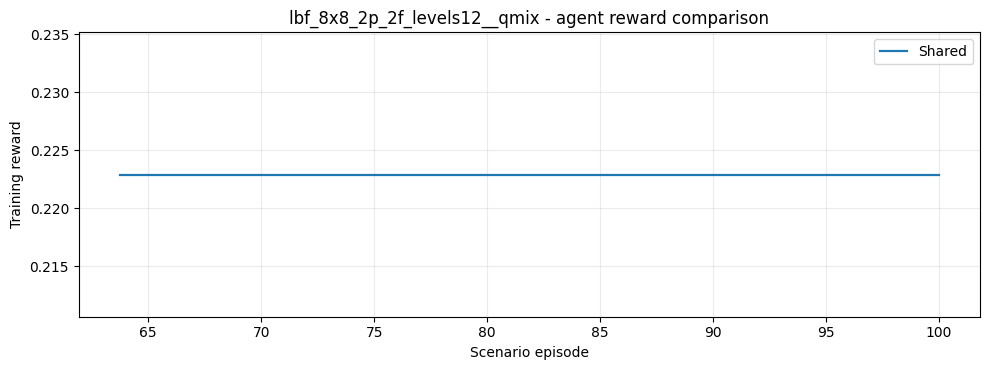

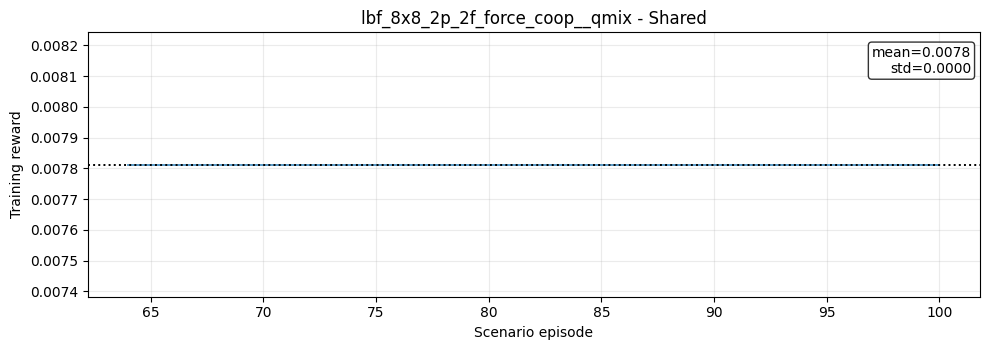

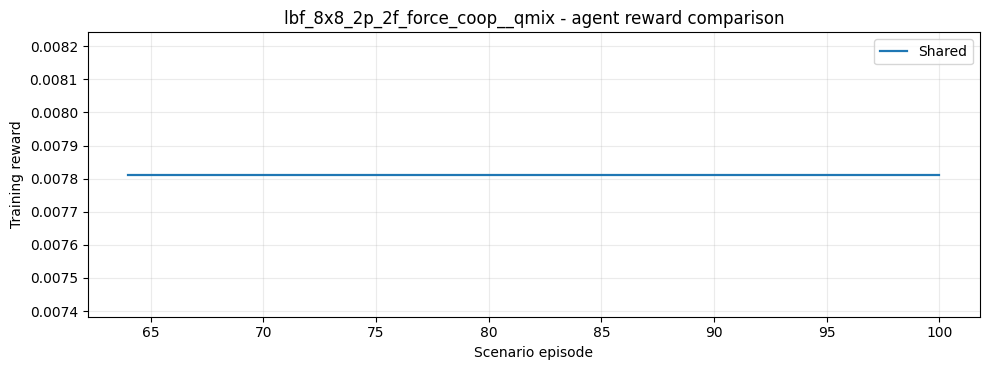

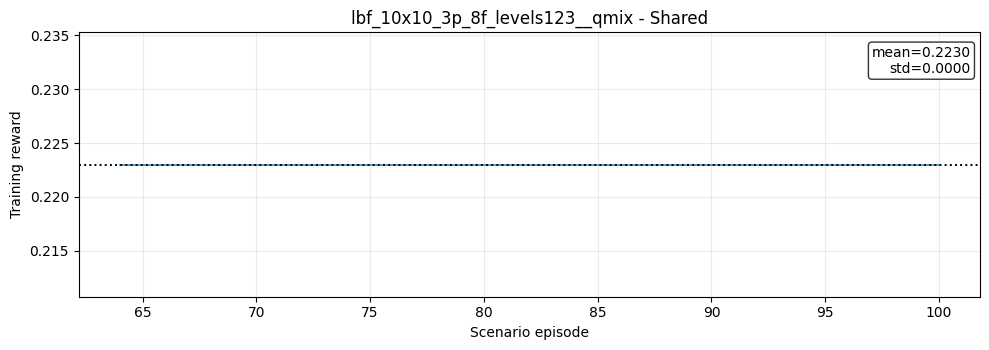

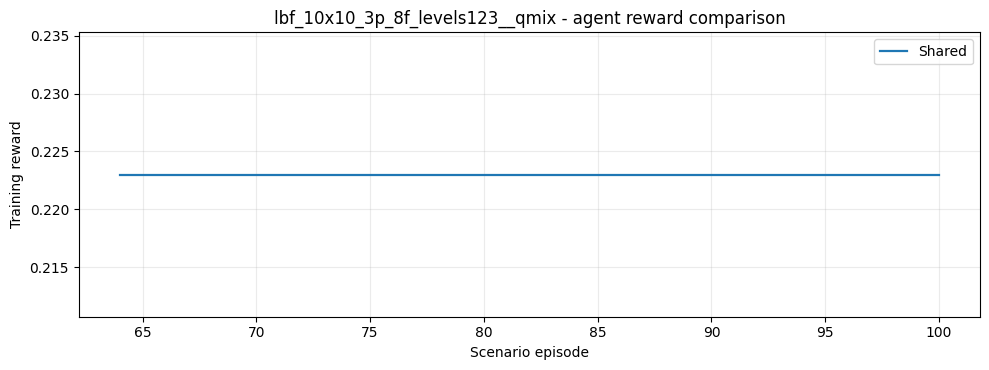

In [15]:
qmix_training_figs = plot_training_rewards(records_qmix)


## QMIX Evaluation Rollouts

For each scenario: run checkpoint evaluation episodes and show one shared-reward boxplot. Video is skipped for EPyMARL Gymma checkpoints because that path does not expose notebook RGB frames.

QMIX lbf_8x8_2p_2f_levels12 checkpoint eval (100 episode) returncode=0
e for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  target[k][_slices] = v.view_as(target[k][_slices])
/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'list'>
  logger.warn(
/home/wowthecoder/epymarl/src/components/episode_buffer.py:110: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[tor

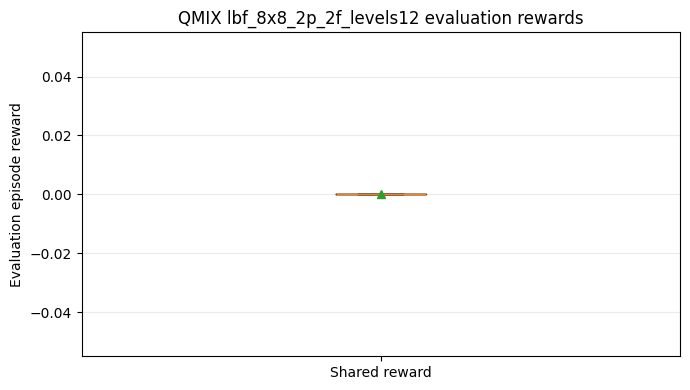

QMIX lbf_8x8_2p_2f_force_coop checkpoint eval (100 episode) returncode=0
e for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  target[k][_slices] = v.view_as(target[k][_slices])
/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'list'>
  logger.warn(
/home/wowthecoder/epymarl/src/components/episode_buffer.py:110: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[t

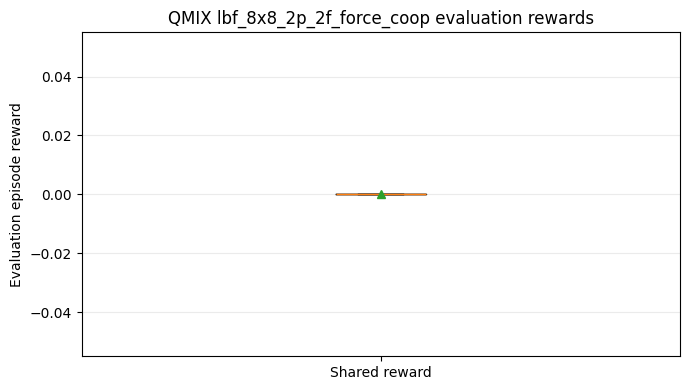

QMIX lbf_10x10_3p_8f_levels123 checkpoint eval (100 episode) returncode=0
e for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  target[k][_slices] = v.view_as(target[k][_slices])
/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:245: UserWarning: WARN: The reward returned by `step()` must be a float, int, np.integer or np.floating, actual type: <class 'list'>
  logger.warn(
/home/wowthecoder/epymarl/src/components/episode_buffer.py:110: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[

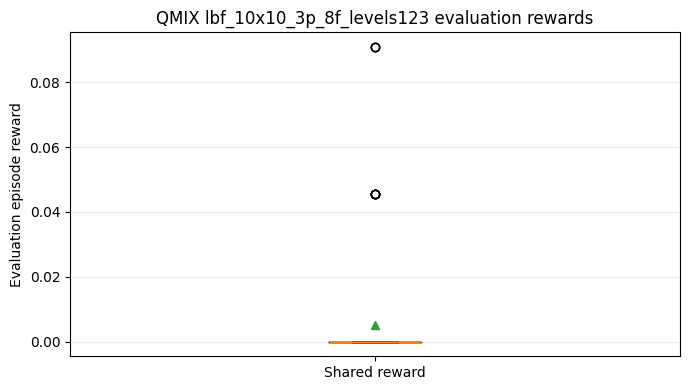

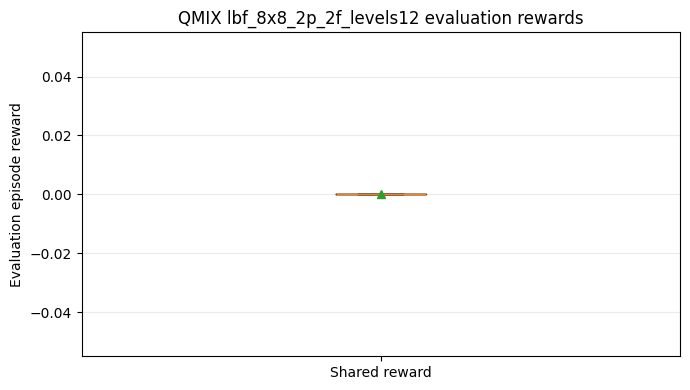

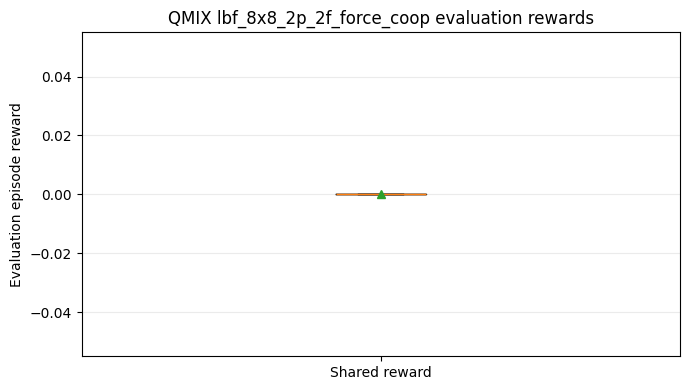

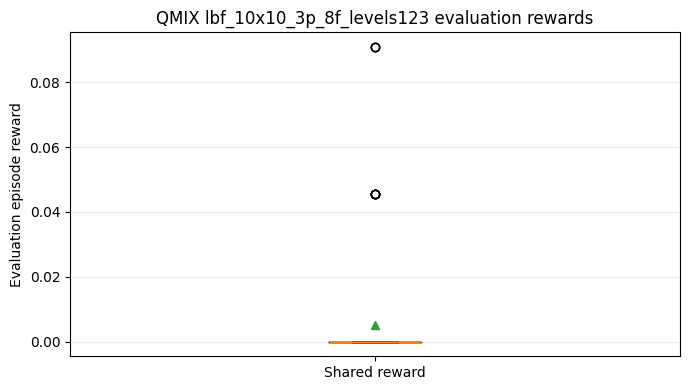

In [16]:
qmix_eval_rollouts = run_epymarl_evaluation_rollouts(records_qmix, common_reward=True)
